In [ ]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Part 1: Single Feature Polynomial Regression
# Part 2: Multivariate Polynomial Regression
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [19]:
# Mount Google Drive and load dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TSURU_cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# All 19 selected features for multivariate part
SELECTED_FEATURES = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Ipy (mA)', 'Ipx (mA)', 'Imz (mA)', 'Imx (mA)', 'Ipz (mA)',
    'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'ΔT_batt_panel (°C)',
    'sin_orbit', 'cos_orbit'
]

# Single feature for Part 1
SINGLE_FEATURE = 'V_panel_avg (mV)'

# Targets
TARGET_PRIMARY   = 'P_solar_total (µW)'
TARGET_SECONDARY = 'Vbat (V)'
TARGET_TERTIARY  = 'Tbatt (℃)'

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Train test split using last fold
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

print(f"\nSingle feature      : {SINGLE_FEATURE}")
print(f"Multivariate features: {len(SELECTED_FEATURES)}")
print(f"Targets             : {TARGET_PRIMARY}, {TARGET_SECONDARY}, {TARGET_TERTIARY}")
print(f"Train size          : {len(train_idx)}")
print(f"Test size           : {len(test_idx)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Single feature      : V_panel_avg (mV)
Multivariate features: 19
Targets             : P_solar_total (µW), Vbat (V), Tbatt (℃)
Train size          : 19383
Test size           : 3876


In [20]:
# ============================================================
# PART 1: SINGLE FEATURE POLYNOMIAL REGRESSION
# Degree 1 to 11 — Find best degree for each target
# ============================================================

targets = {
    'P_solar_total': (df[[SINGLE_FEATURE]], df[TARGET_PRIMARY]),
    'Vbat'         : (df[[SINGLE_FEATURE]], df[TARGET_SECONDARY]),
    'Tbatt'        : (df[[SINGLE_FEATURE]], df[TARGET_TERTIARY])
}

# Store results for all degrees and all targets
degree_results = {name: {'train_r2': [], 'test_r2': [], 'rmse': [], 'mae': []}
                  for name in targets}

DEGREES = range(1, 17)

print("Testing degrees 1 to 11 for each target...")
print("=" * 65)

for name, (X, y) in targets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    print(f"\nTarget: {y.name}")
    print(f"{'Degree':<8} {'Train R2':>10} {'Test R2':>10} {'RMSE':>15} {'MAE':>15}")
    print("-" * 60)

    for deg in DEGREES:
        pipe = Pipeline([
            ('poly',  PolynomialFeatures(degree=deg, include_bias=False)),
            ('scaler', StandardScaler()),
            ('model', LinearRegression())
        ])
        pipe.fit(X_train, y_train)

        train_r2 = r2_score(y_train, pipe.predict(X_train))
        y_pred   = pipe.predict(X_test)
        test_r2  = r2_score(y_test, y_pred)
        rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
        mae      = mean_absolute_error(y_test, y_pred)

        degree_results[name]['train_r2'].append(train_r2)
        degree_results[name]['test_r2'].append(test_r2)
        degree_results[name]['rmse'].append(rmse)
        degree_results[name]['mae'].append(mae)

        print(f"{deg:<8} {train_r2:>10.4f} {test_r2:>10.4f} "
              f"{rmse:>15.4f} {mae:>15.4f}")

    best_deg = DEGREES[np.argmax(degree_results[name]['test_r2'])]
    best_r2  = max(degree_results[name]['test_r2'])
    print(f"\n  Best degree: {best_deg} | Best Test R2: {best_r2:.4f}")

Testing degrees 1 to 11 for each target...

Target: P_solar_total (µW)
Degree     Train R2    Test R2            RMSE             MAE
------------------------------------------------------------
1            0.5738     0.5723     579059.9313     369745.4891
2            0.6629     0.6354     534680.8377     329573.5155
3            0.6681     0.6443     528054.9563     326562.4153
4            0.6748     0.6519     522445.2186     314695.5423
5            0.6748     0.6518     522483.7693     314804.1316
6            0.6756     0.6540     520825.7171     317420.8230
7            0.6769     0.6570     518577.8613     312350.7393
8            0.6770     0.6570     518594.3327     313542.1200
9            0.6782     0.6606     515812.4546     310997.8039
10           0.6798     0.6628     514149.8555     309318.8813
11           0.6798     0.6626     514336.0366     308886.1231
12           0.6809     0.6635     513637.7490     307786.9420
13           0.6809     0.6634     513741.4486   

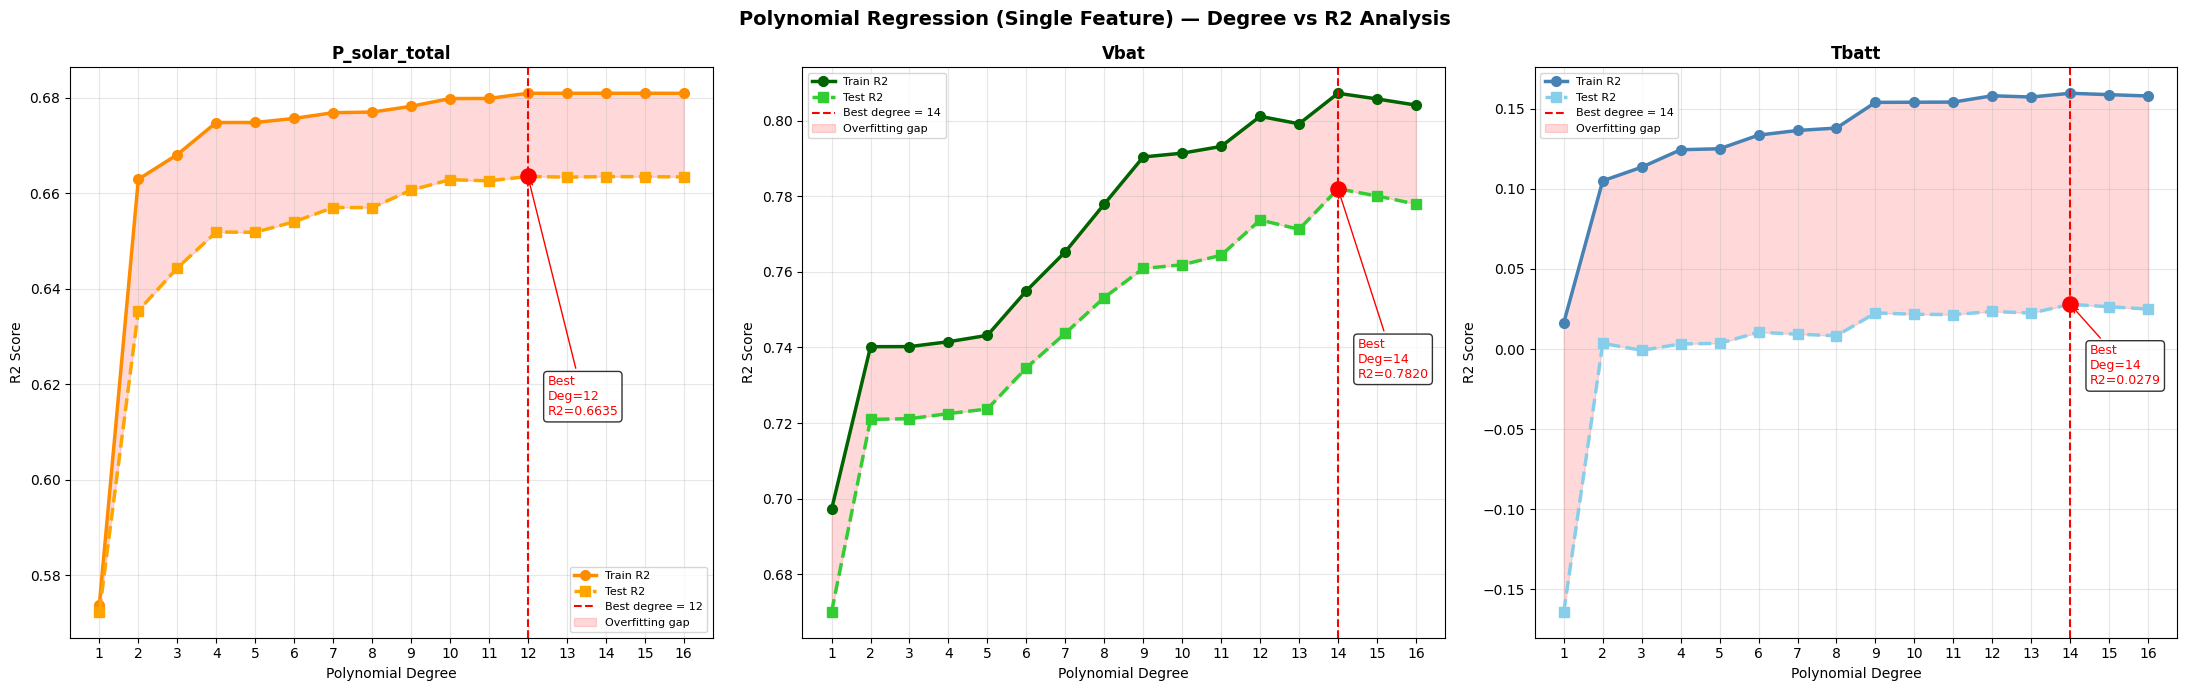

Degree vs R2 plot saved.


In [21]:
# ============================================================
# PART 1: DEGREE vs R2 VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Polynomial Regression (Single Feature) — Degree vs R2 Analysis',
             fontsize=14, fontweight='bold')

target_names  = ['P_solar_total', 'Vbat', 'Tbatt']
colors_train  = ['darkorange', 'darkgreen', 'steelblue']
colors_test   = ['orange', 'limegreen', 'skyblue']
degrees_list  = list(DEGREES)

for idx, name in enumerate(target_names):
    ax         = axes[idx]
    train_r2   = degree_results[name]['train_r2']
    test_r2    = degree_results[name]['test_r2']
    best_deg   = degrees_list[np.argmax(test_r2)]
    best_r2    = max(test_r2)

    ax.plot(degrees_list, train_r2,
            color=colors_train[idx], linewidth=2.5,
            marker='o', markersize=7,
            label='Train R2', linestyle='-')
    ax.plot(degrees_list, test_r2,
            color=colors_test[idx], linewidth=2.5,
            marker='s', markersize=7,
            label='Test R2', linestyle='--')

    # Highlight best degree
    ax.axvline(x=best_deg, color='red', linestyle='--',
               linewidth=1.5, label=f'Best degree = {best_deg}')
    ax.scatter([best_deg], [best_r2],
               color='red', s=120, zorder=5)
    ax.annotate(f'Best\nDeg={best_deg}\nR2={best_r2:.4f}',
                xy=(best_deg, best_r2),
                xytext=(best_deg + 0.5, best_r2 - 0.05),
                fontsize=9, color='red',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='red'))

    # Shade overfitting region
    ax.fill_between(degrees_list, train_r2, test_r2,
                    alpha=0.15, color='red',
                    label='Overfitting gap')

    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Polynomial Degree')
    ax.set_ylabel('R2 Score')
    ax.set_xticks(degrees_list)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_degree_vs_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Degree vs R2 plot saved.")

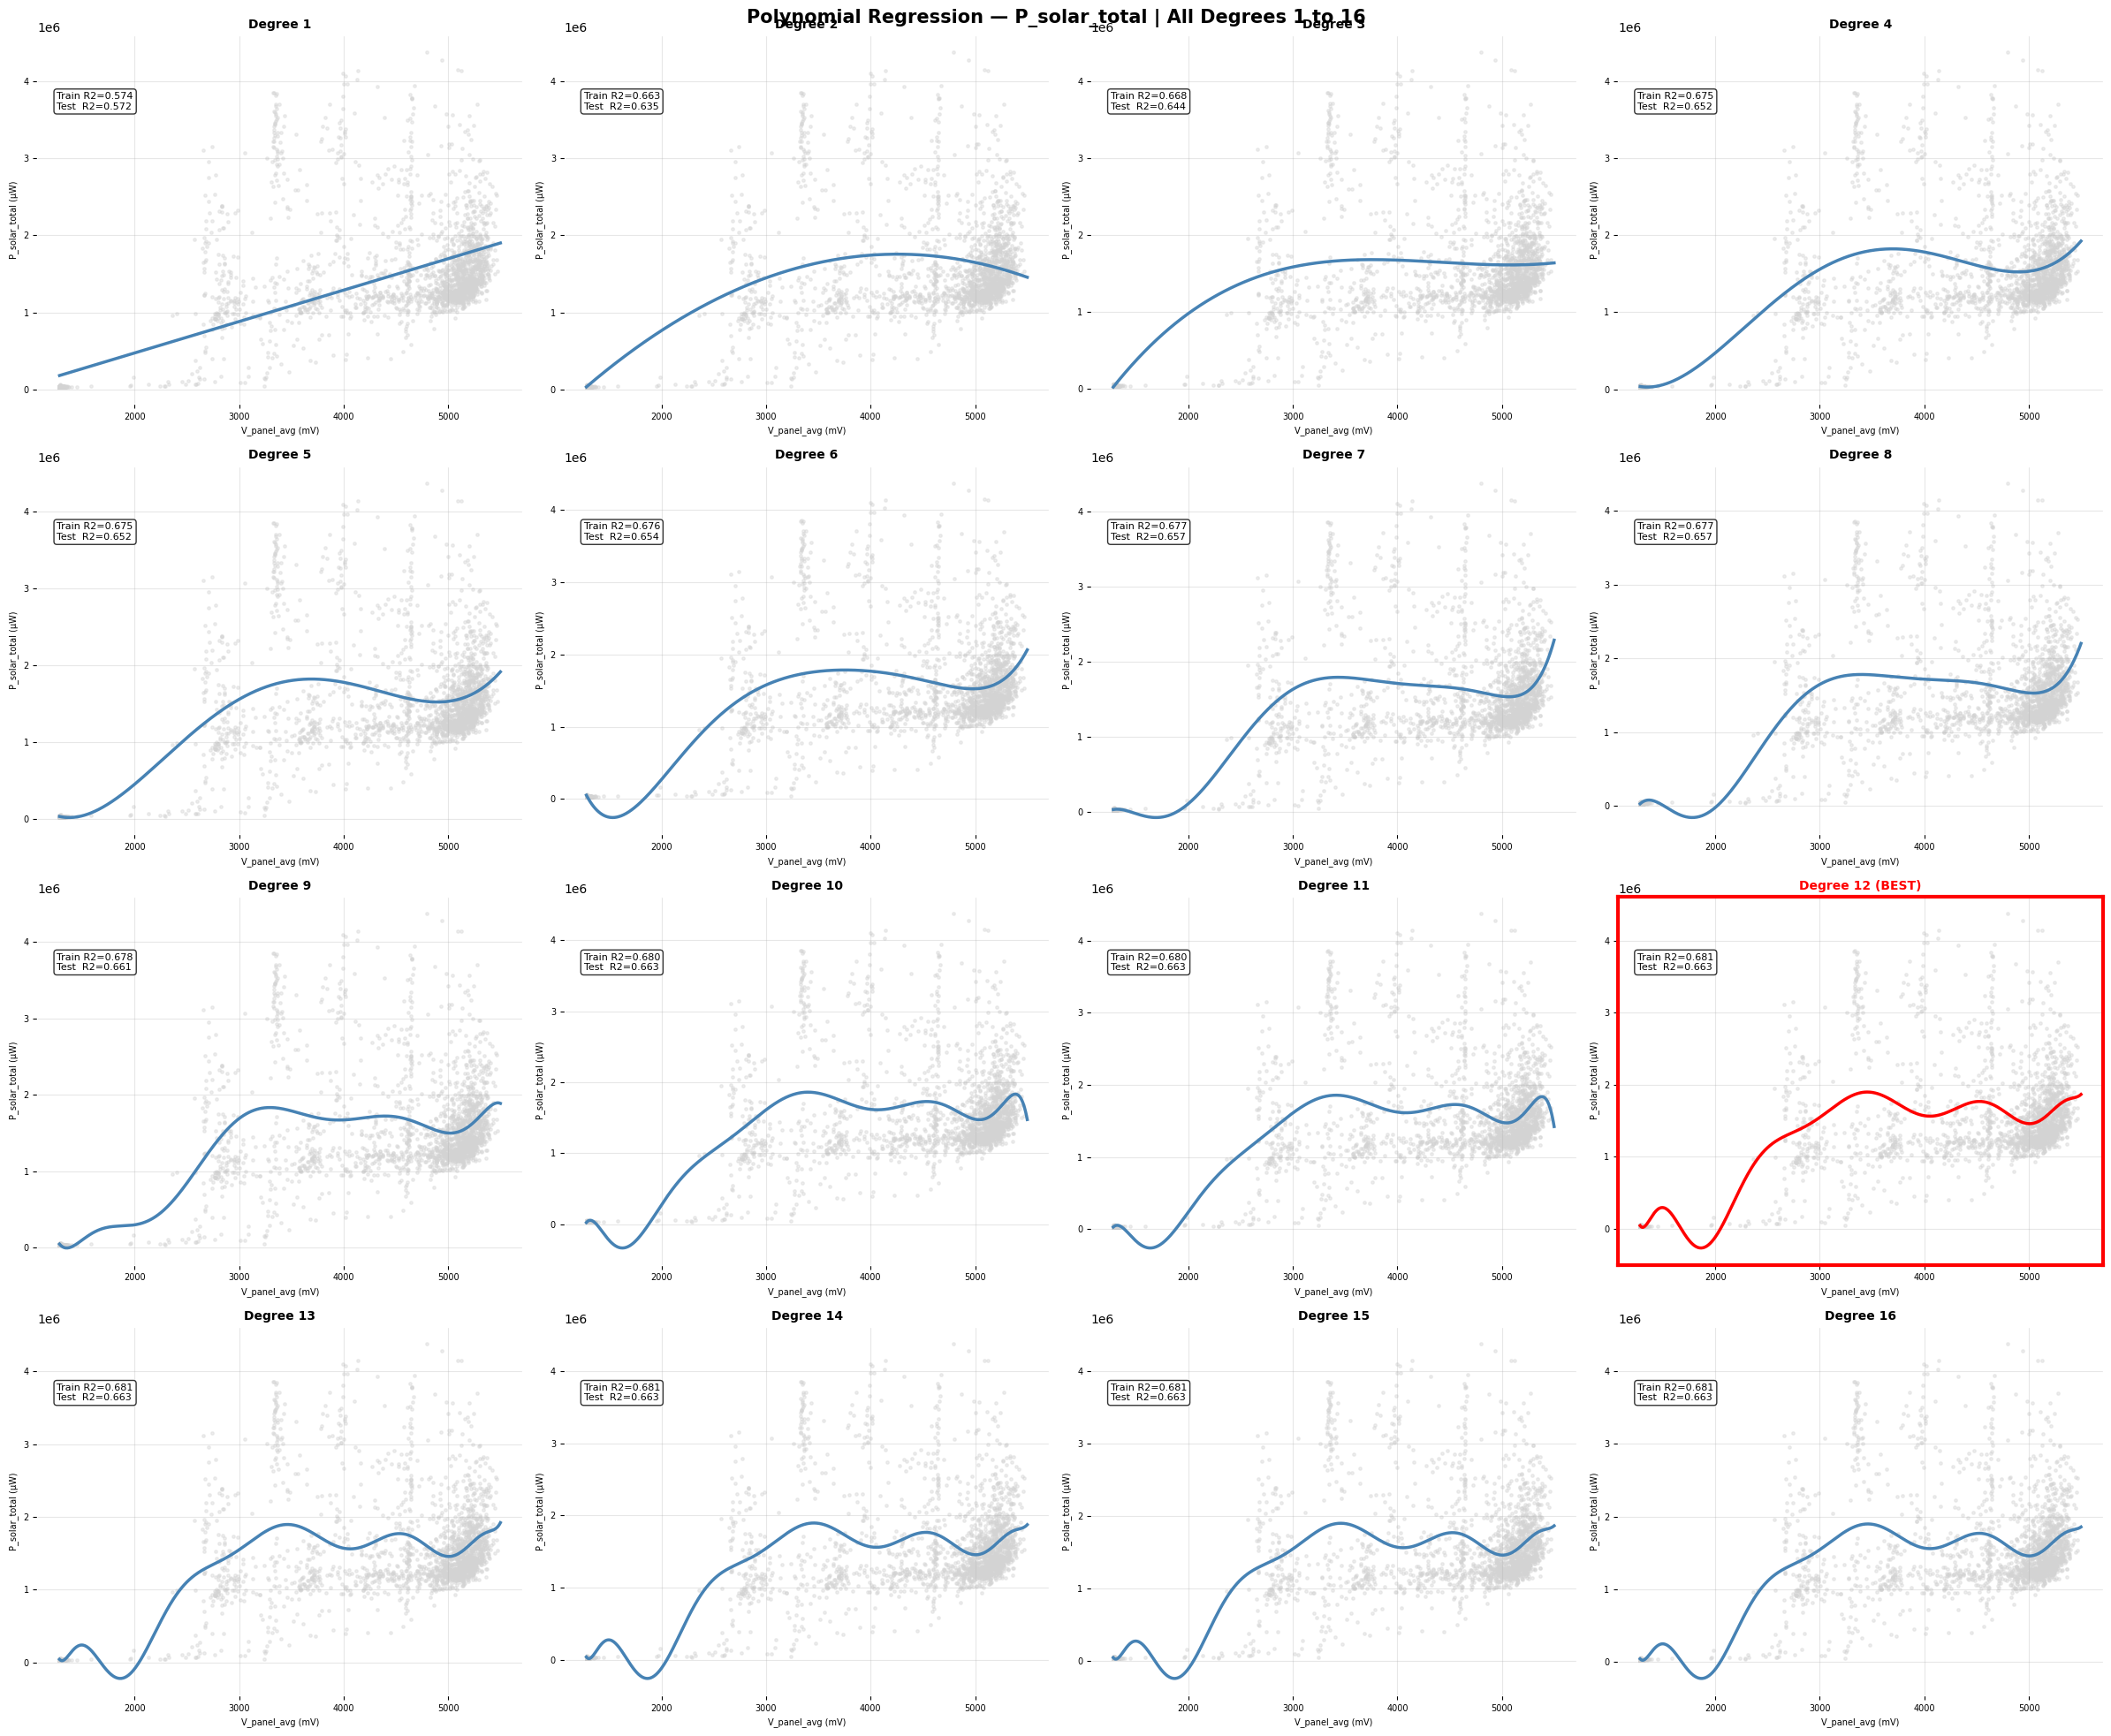

Individual degree plots saved for P_solar_total


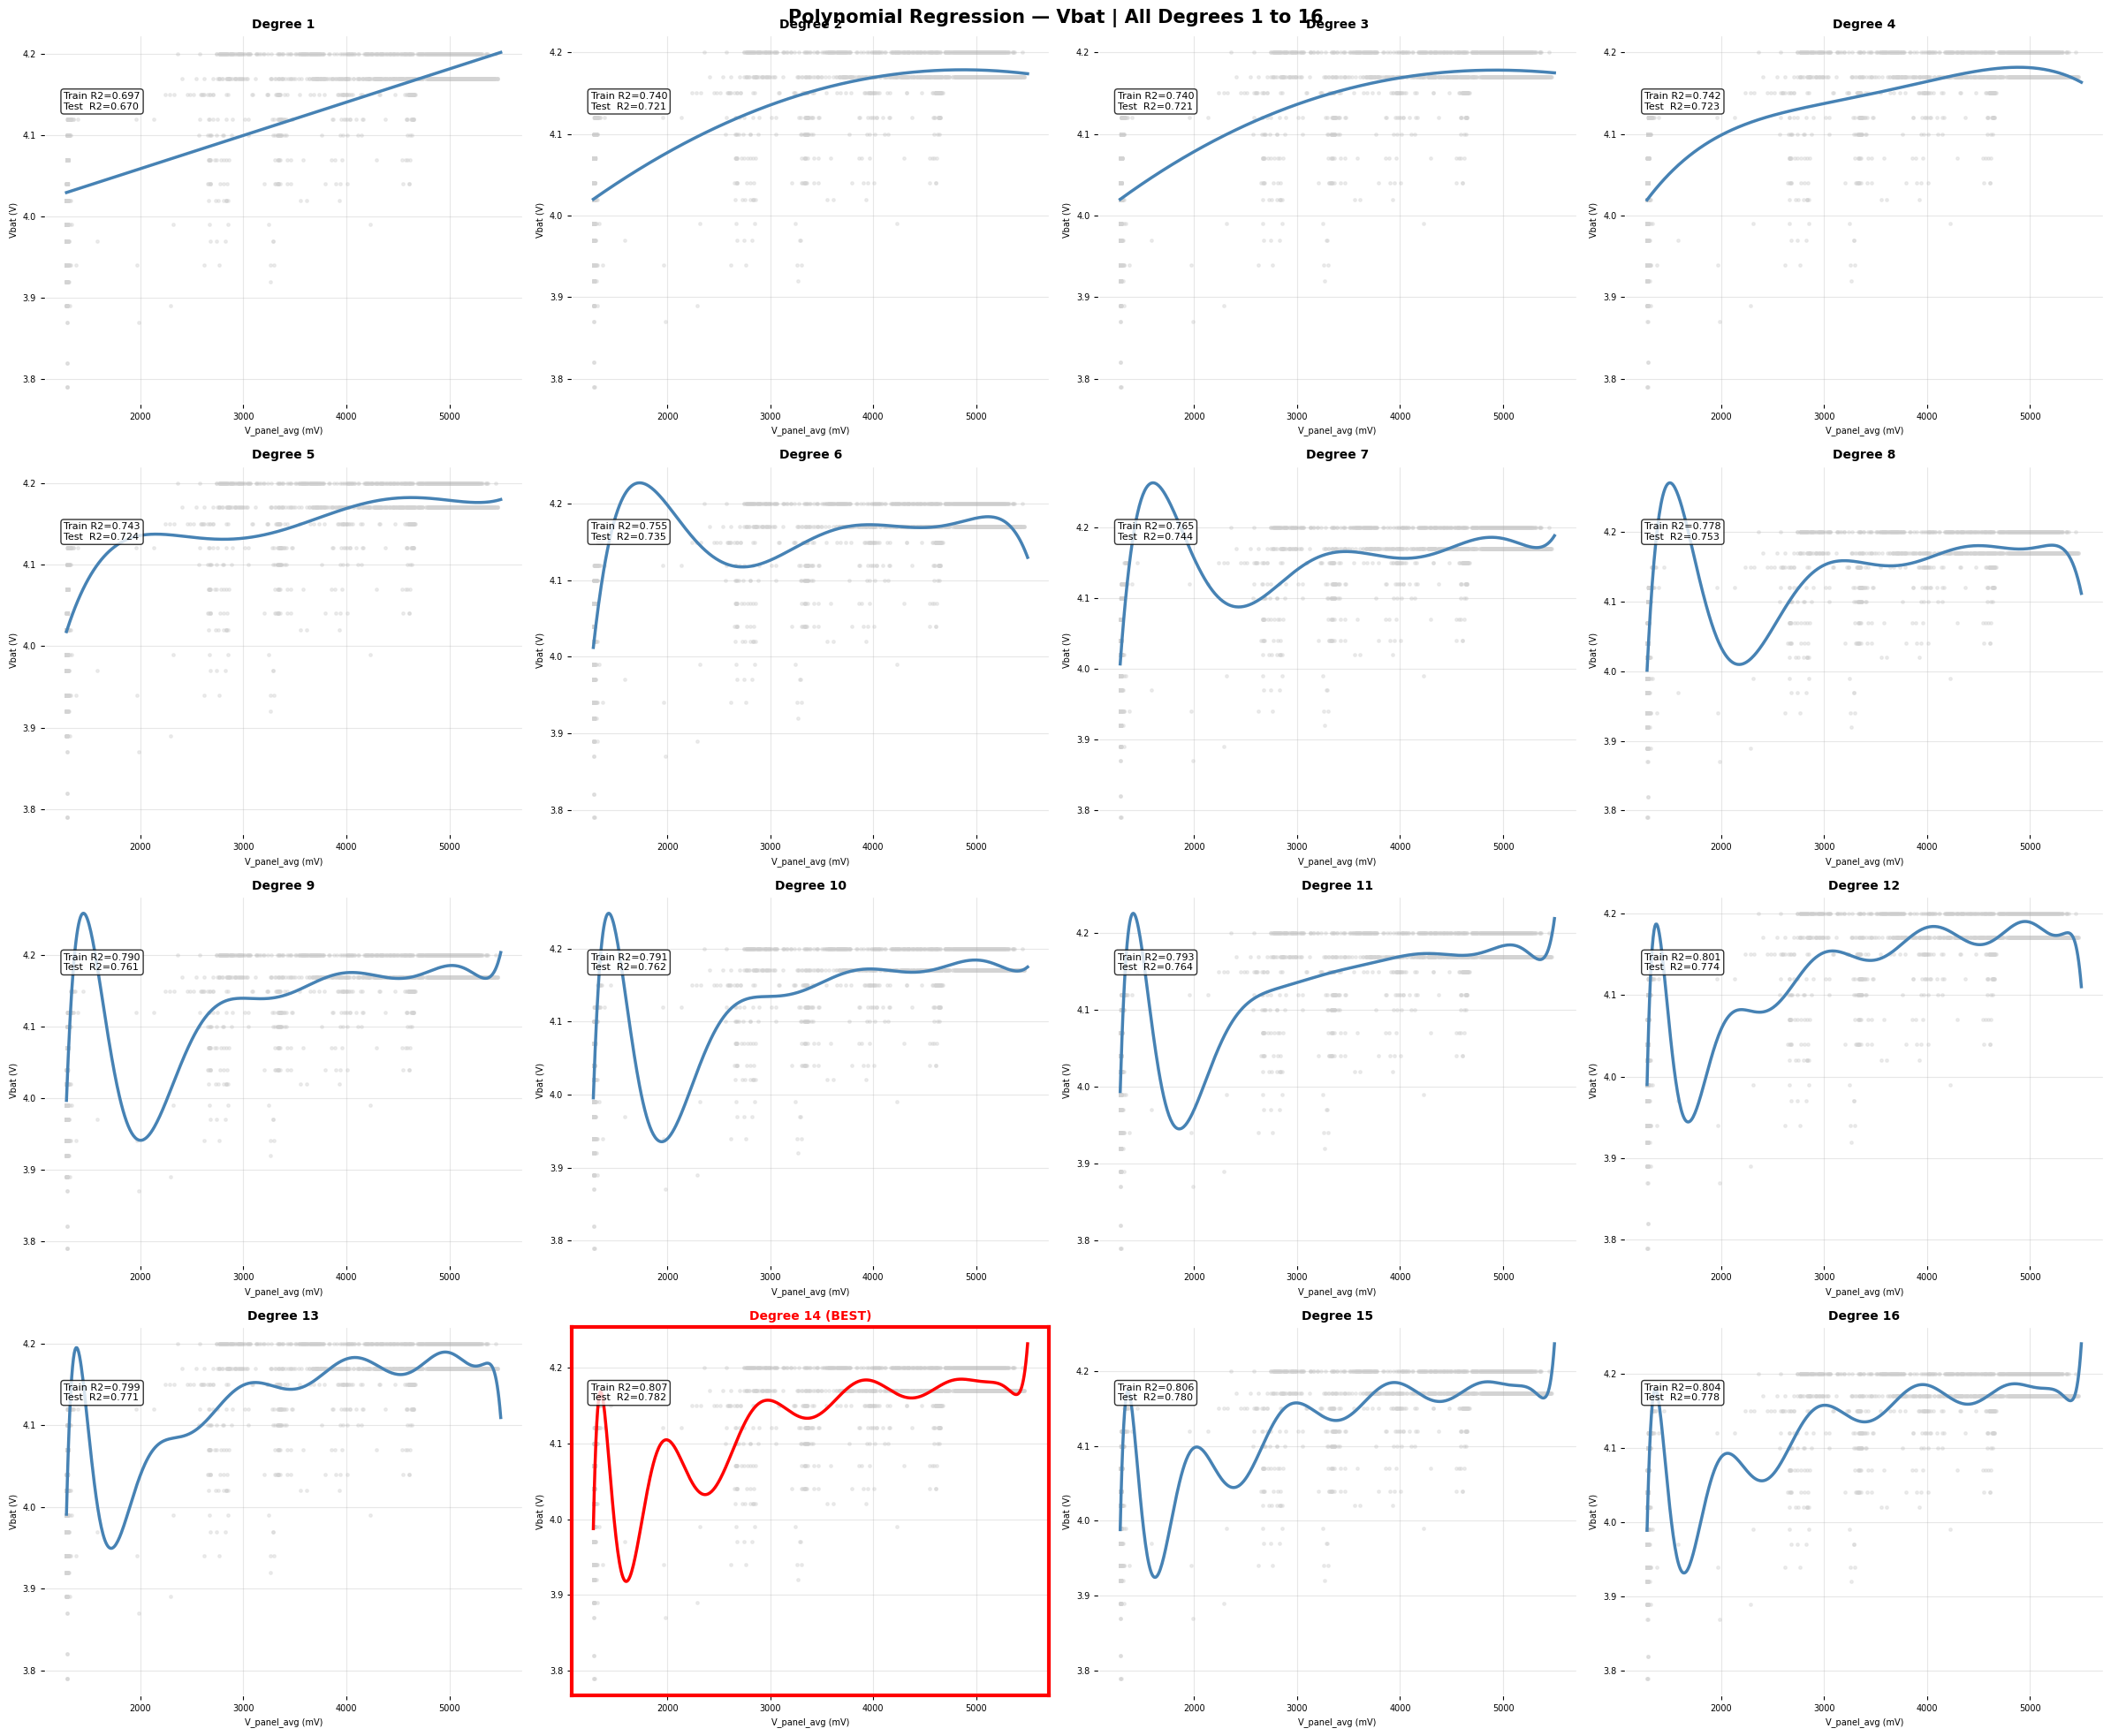

Individual degree plots saved for Vbat


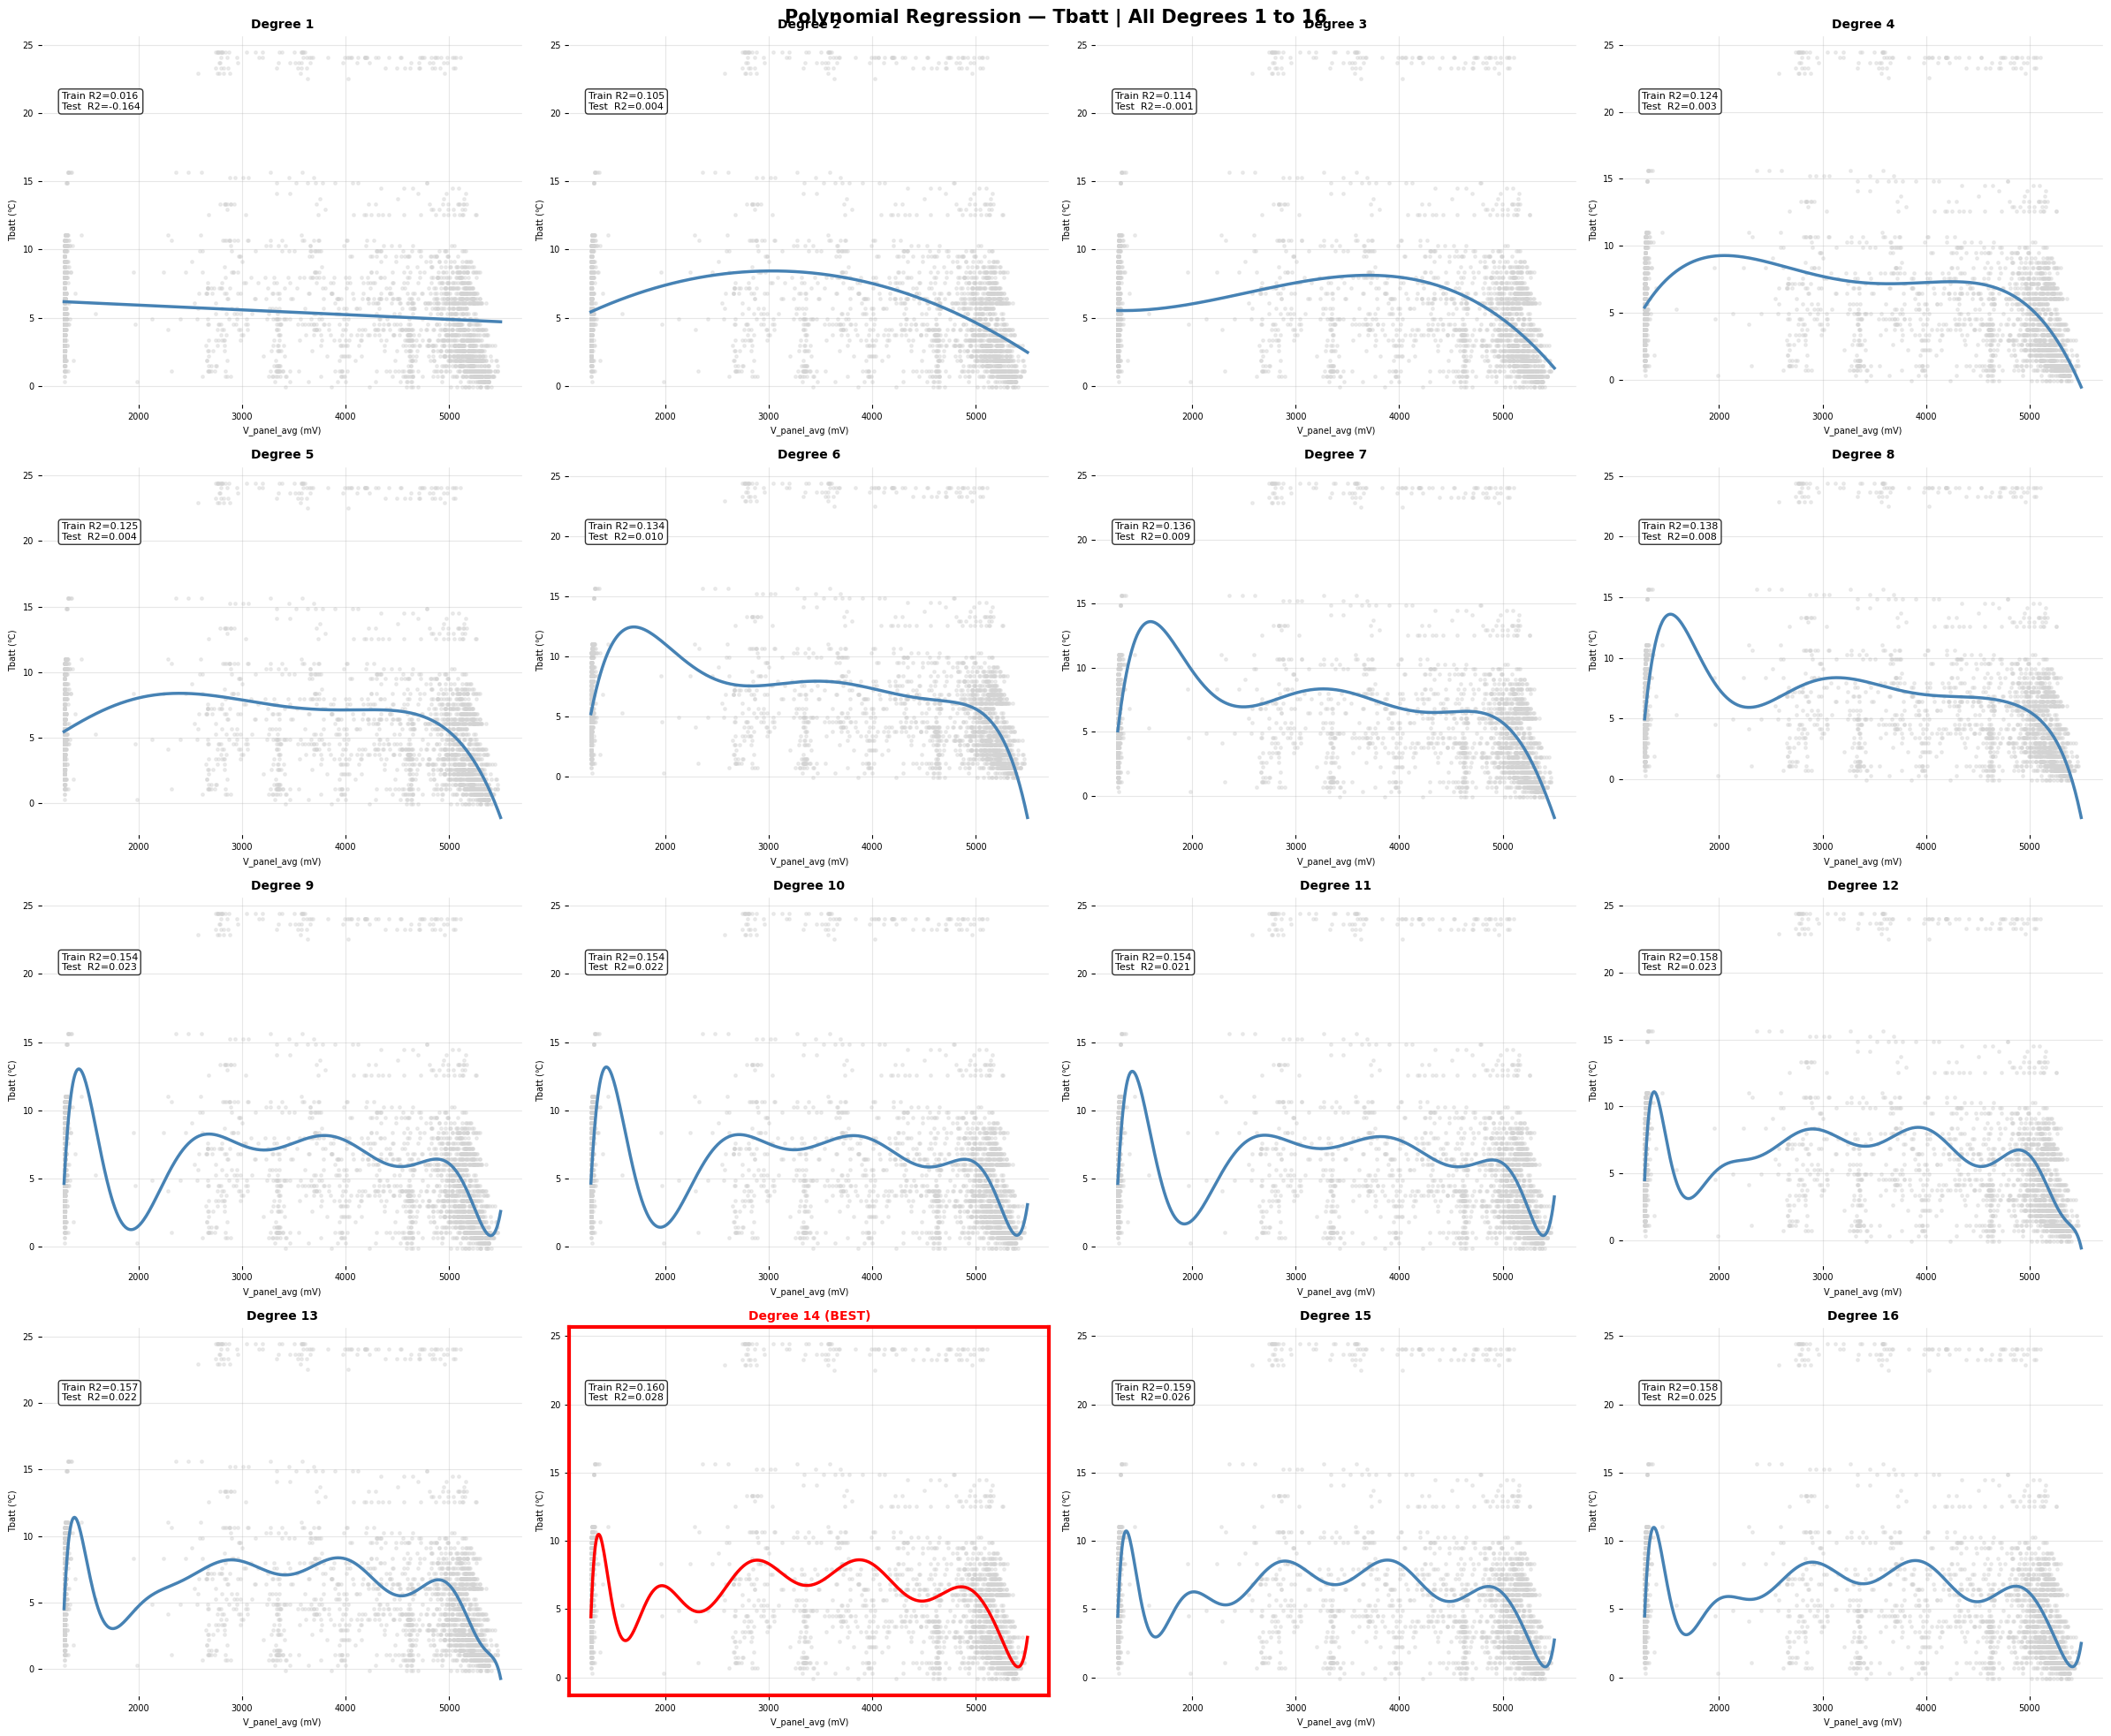

Individual degree plots saved for Tbatt


In [22]:
# ============================================================
# ALL DEGREES PLOTTED INDIVIDUALLY — 1 TO 16
# ============================================================

for name, ytarget in zip(['P_solar_total', 'Vbat', 'Tbatt'],
                          [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):

    X, y    = target_map[name]
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    best_deg = best_degrees[name]

    fig, axes = plt.subplots(4, 4, figsize=(24, 20))
    fig.suptitle(f'Polynomial Regression — {name} | All Degrees 1 to 16',
                 fontsize=15, fontweight='bold')

    sample = df.sample(3000, random_state=42)
    x_range = np.linspace(df[SINGLE_FEATURE].min(),
                          df[SINGLE_FEATURE].max(), 500).reshape(-1, 1)

    for deg in range(1, 17):
        row = (deg - 1) // 4
        col = (deg - 1) % 4
        ax  = axes[row, col]

        pipe = Pipeline([
            ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
            ('scaler', StandardScaler()),
            ('model',  LinearRegression())
        ])
        pipe.fit(X_train, y_train)
        y_curve  = pipe.predict(x_range)
        test_r2  = degree_results[name]['test_r2'][deg - 1]
        train_r2 = degree_results[name]['train_r2'][deg - 1]

        # Highlight best degree
        border_color = 'red' if deg == best_deg else 'white'
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3 if deg == best_deg else 1)

        ax.scatter(sample[SINGLE_FEATURE], sample[ytarget],
                   color='lightgray', alpha=0.4, s=6, zorder=1)
        curve_color = 'red' if deg == best_deg else 'steelblue'
        ax.plot(x_range, y_curve,
                color=curve_color, linewidth=2.5, zorder=2)

        title = f'Degree {deg}'
        if deg == best_deg:
            title += ' (BEST)'
        ax.set_title(title, fontweight='bold',
                     fontsize=10,
                     color='red' if deg == best_deg else 'black')
        ax.set_xlabel(SINGLE_FEATURE, fontsize=7)
        ax.set_ylabel(ytarget, fontsize=7)
        ax.annotate(f'Train R2={train_r2:.3f}\nTest  R2={test_r2:.3f}',
                    xy=(0.04, 0.80), xycoords='axes fraction',
                    fontsize=8,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)

    plt.tight_layout()
    fname = f'02c_individual_degrees_{name}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Individual degree plots saved for {name}")

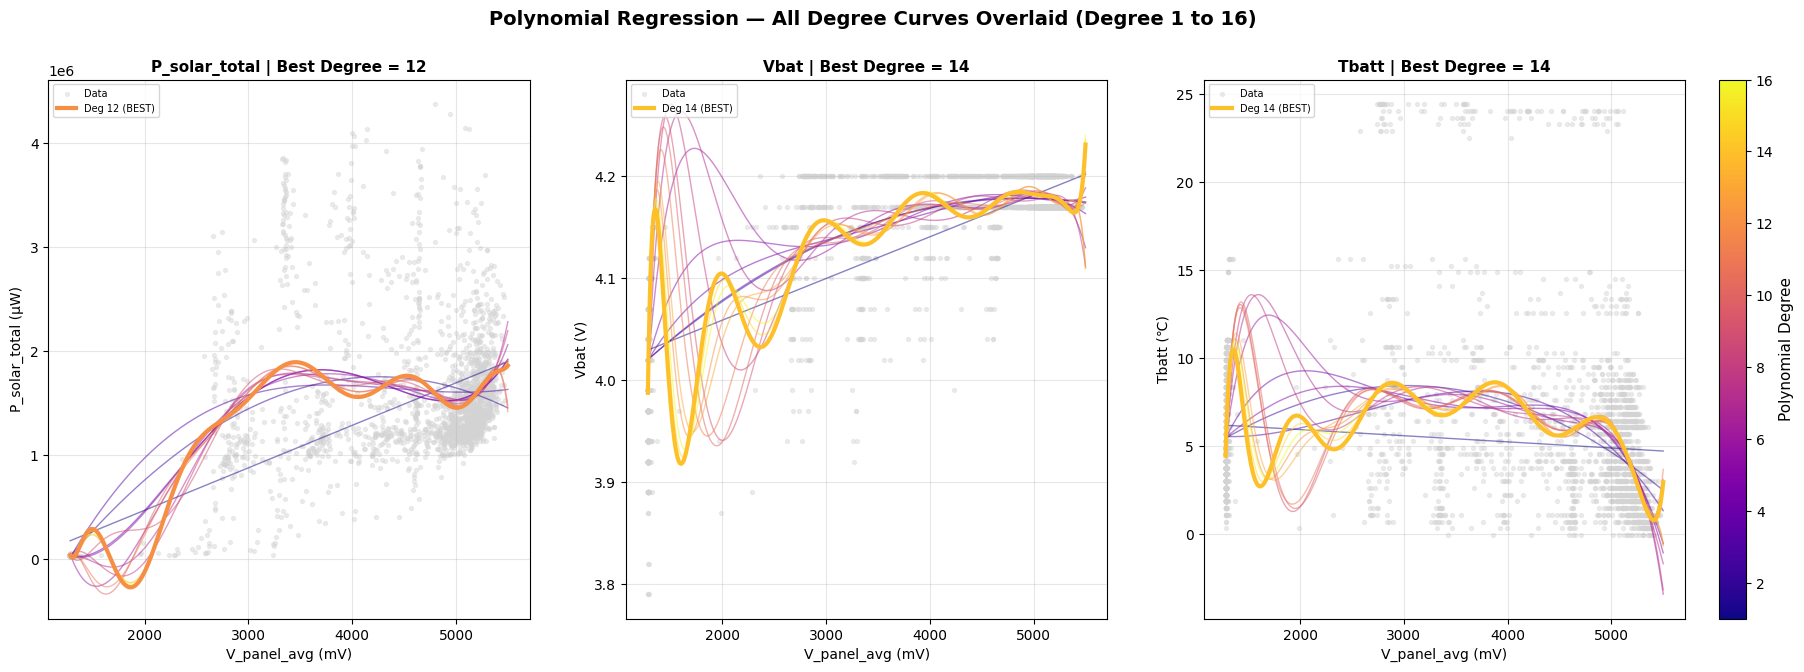

All curves overlaid plot saved.


In [23]:
# ============================================================
# ALL POLYNOMIAL CURVES OVERLAID — DEGREE 1 TO 16
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Polynomial Regression — All Degree Curves Overlaid (Degree 1 to 16)',
             fontsize=14, fontweight='bold')

import matplotlib.cm as cm
colors_deg = cm.plasma(np.linspace(0, 1, 16))

target_list  = ['P_solar_total', 'Vbat', 'Tbatt']
y_targets    = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]
sample       = df.sample(3000, random_state=42)
x_range      = np.linspace(df[SINGLE_FEATURE].min(),
                           df[SINGLE_FEATURE].max(), 500).reshape(-1, 1)

for idx, (name, ytarget) in enumerate(zip(target_list, y_targets)):
    ax      = axes[idx]
    X, y    = target_map[name]
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_test  = y.iloc[test_idx]
    best_deg = best_degrees[name]

    # Scatter data
    ax.scatter(sample[SINGLE_FEATURE], sample[ytarget],
               color='lightgray', alpha=0.4, s=8, label='Data', zorder=1)

    for deg_idx, deg in enumerate(range(1, 17)):
        pipe = Pipeline([
            ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
            ('scaler', StandardScaler()),
            ('model',  LinearRegression())
        ])
        pipe.fit(X_train, y_train)
        y_curve = pipe.predict(x_range)

        lw    = 3.0 if deg == best_deg else 1.0
        alpha = 1.0 if deg == best_deg else 0.5
        label = f'Deg {deg} (BEST)' if deg == best_deg else f'Deg {deg}'

        ax.plot(x_range, y_curve,
                color=colors_deg[deg_idx],
                linewidth=lw,
                alpha=alpha,
                label=label,
                zorder=3 if deg == best_deg else 2)

    ax.set_title(f'{name} | Best Degree = {best_deg}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel(SINGLE_FEATURE)
    ax.set_ylabel(ytarget)
    ax.grid(True, alpha=0.3)

    # Colorbar style legend — only show best + every 4th degree
    handles, labels = ax.get_legend_handles_labels()
    selected = [i for i, l in enumerate(labels)
                if 'BEST' in l or 'Data' in l or
                any(f'Deg {d} ' in l for d in [1, 4, 8, 12, 16])]
    ax.legend([handles[i] for i in selected],
              [labels[i] for i in selected],
              fontsize=7, loc='upper left')

# Colorbar for degree reference
sm = plt.cm.ScalarMappable(cmap='plasma',
                            norm=plt.Normalize(vmin=1, vmax=16))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical',
                    fraction=0.02, pad=0.02)
cbar.set_label('Polynomial Degree', fontsize=11)

plt.savefig('02b_all_curves_overlaid.png', dpi=150, bbox_inches='tight')
plt.show()
print("All curves overlaid plot saved.")

## Polynomial Regression Performance Analysis

### P_solar_total

- R² improves from degree 1 to 4, then plateaus  
- Overfitting gap grows steadily  
- Best at degree 12 but marginal improvement after degree 4  

---

### Vbat

- Consistently improving across all degrees with best at 14
- Moderate overfitting gap throughout  

---

### Tbatt

- Train R² keeps climbing but test R² stays near zero across all degrees  
- Confirming battery temperature simply cannot be predicted from panel sensors regardless of polynomial degree  

Best degrees selected:
  P_solar_total: degree 12
  Vbat: degree 14
  Tbatt: degree 14


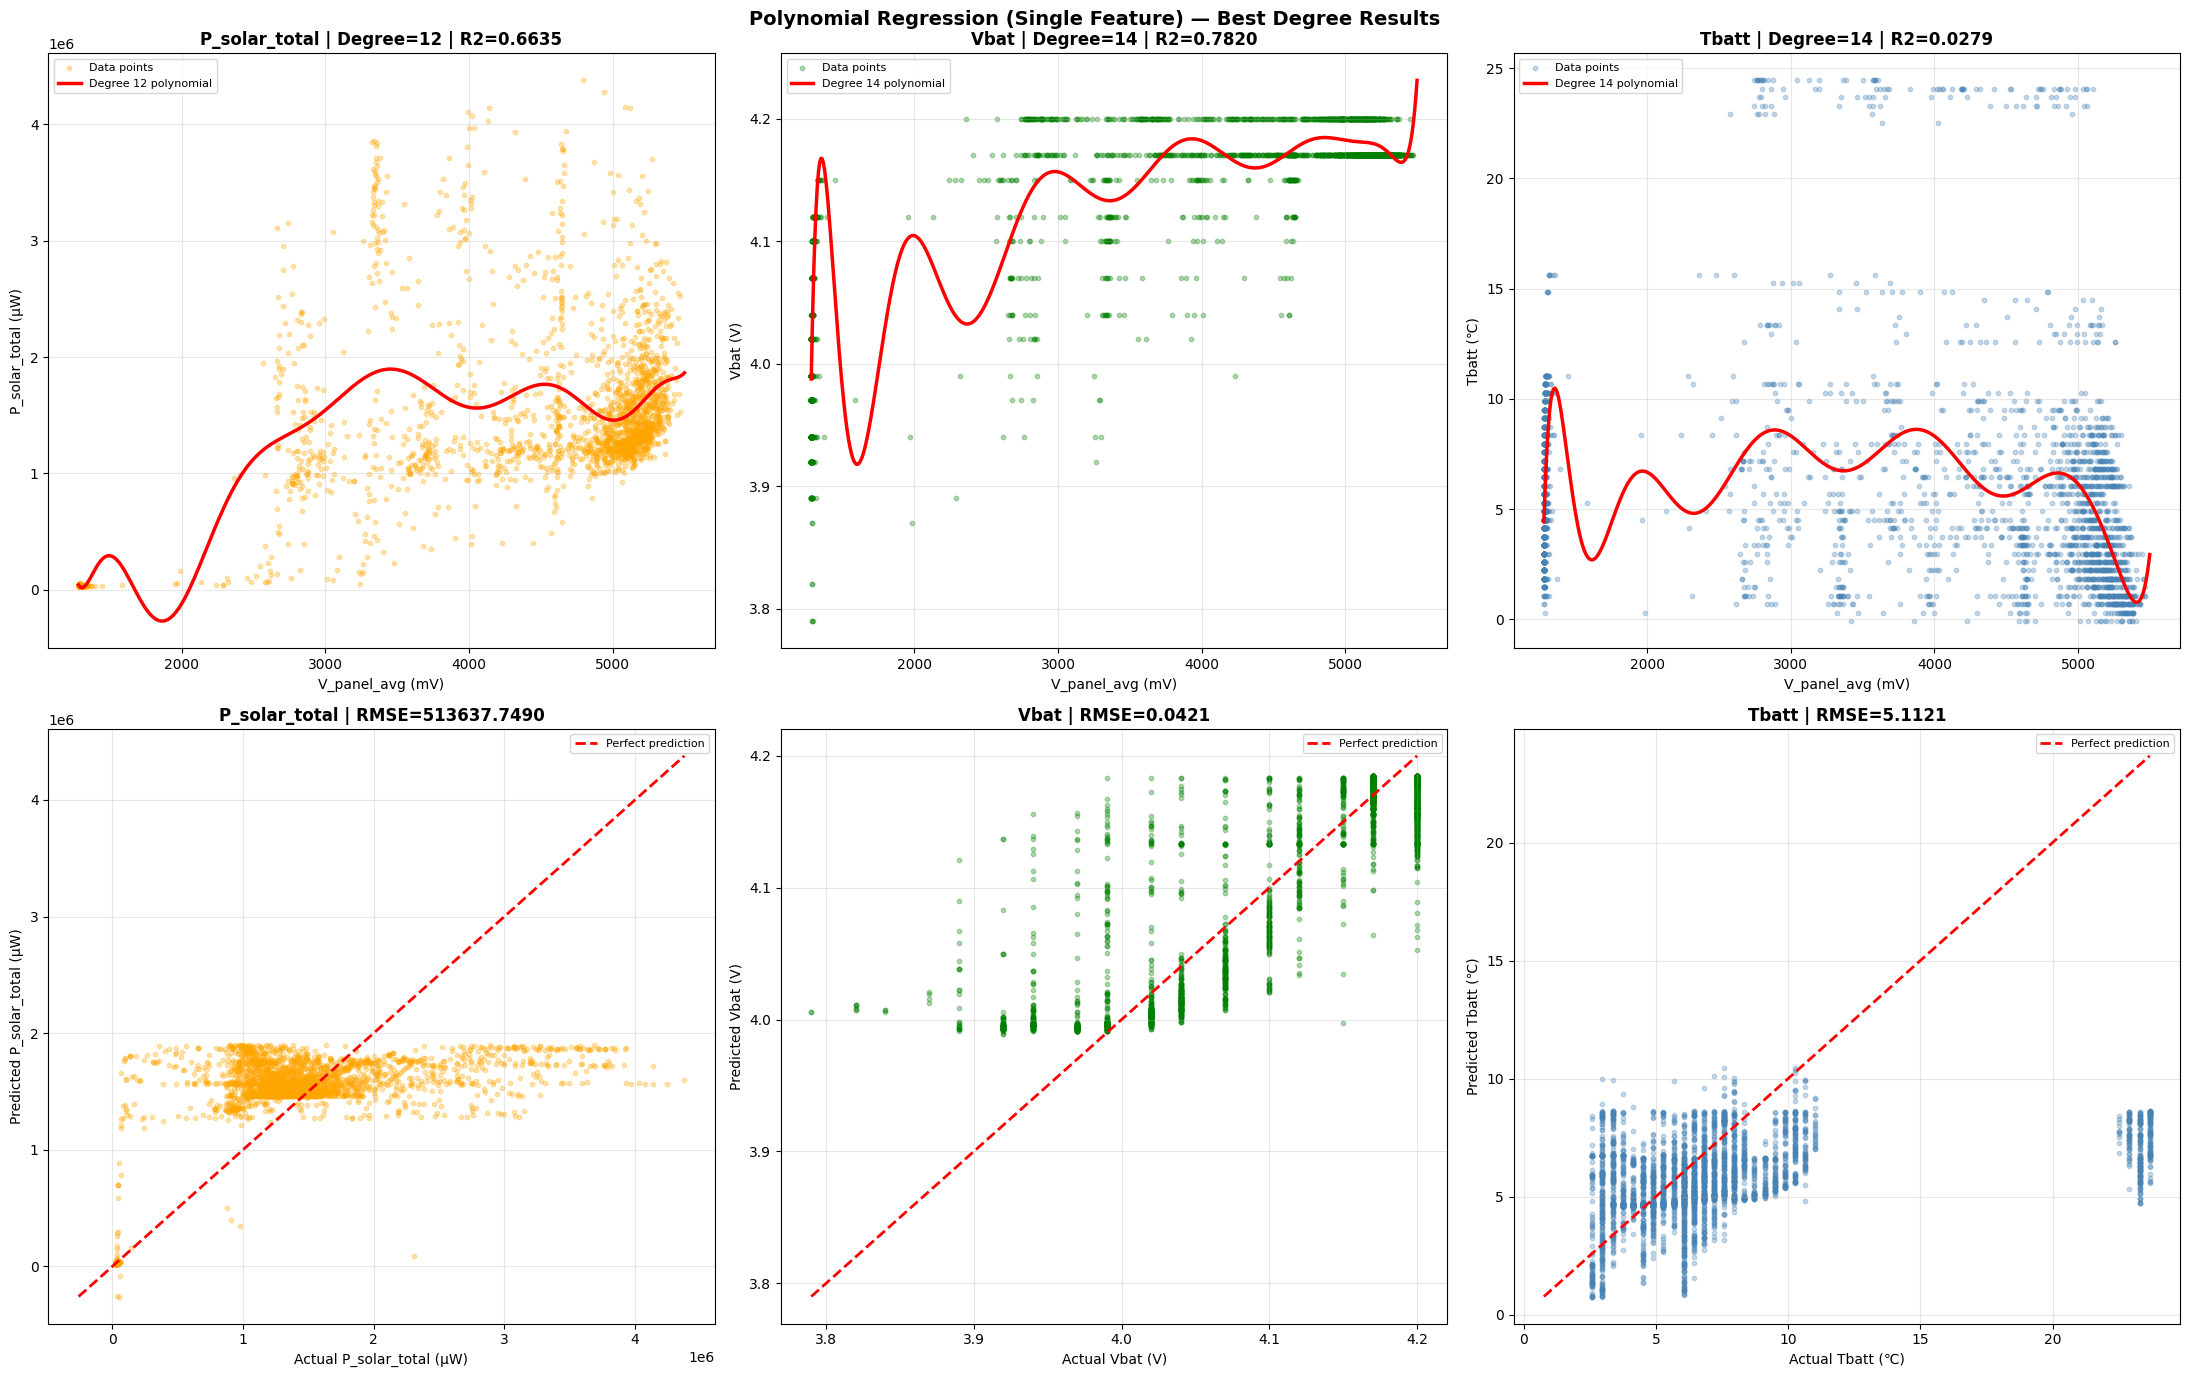

Best degree results plot saved.


In [24]:
# ============================================================
# PART 1: BEST DEGREE MODEL — FITTING AND VISUALIZATION
# ============================================================

best_degrees = {
    'P_solar_total': degrees_list[np.argmax(degree_results['P_solar_total']['test_r2'])],
    'Vbat'         : degrees_list[np.argmax(degree_results['Vbat']['test_r2'])],
    'Tbatt'        : degrees_list[np.argmax(degree_results['Tbatt']['test_r2'])]
}

print("Best degrees selected:")
for name, deg in best_degrees.items():
    print(f"  {name}: degree {deg}")

best_pipes   = {}
best_metrics = {}

target_map = {
    'P_solar_total': (df[[SINGLE_FEATURE]], df[TARGET_PRIMARY]),
    'Vbat'         : (df[[SINGLE_FEATURE]], df[TARGET_SECONDARY]),
    'Tbatt'        : (df[[SINGLE_FEATURE]], df[TARGET_TERTIARY])
}

for name, deg in best_degrees.items():
    X, y    = target_map[name]
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    best_pipes[name]   = (pipe, y_pred, y_test)
    best_metrics[name] = {
        'R2'  : r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE' : mean_absolute_error(y_test, y_pred),
        'MSE' : mean_squared_error(y_test, y_pred)
    }

# ---- Visualization ----
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Polynomial Regression (Single Feature) — Best Degree Results',
             fontsize=14, fontweight='bold')

plot_colors = ['orange', 'green', 'steelblue']
target_list = ['P_solar_total', 'Vbat', 'Tbatt']
x_features  = [SINGLE_FEATURE, SINGLE_FEATURE, SINGLE_FEATURE]
y_targets   = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]

for idx, name in enumerate(target_list):
    X, y    = target_map[name]
    pipe    = best_pipes[name][0]
    y_pred  = best_picks = best_pipes[name][1]
    y_test  = best_pipes[name][2]
    deg     = best_degrees[name]
    r2      = best_metrics[name]['R2']
    rmse    = best_metrics[name]['RMSE']
    clr     = plot_colors[idx]

    # Row 1: Polynomial curve fit
    ax = axes[0, idx]
    sample = df.sample(3000, random_state=42)
    ax.scatter(sample[SINGLE_FEATURE], sample[y_targets[idx]],
               color=clr, alpha=0.3, s=10, label='Data points')
    x_range = np.linspace(df[SINGLE_FEATURE].min(),
                          df[SINGLE_FEATURE].max(), 500).reshape(-1, 1)
    y_curve = pipe.predict(x_range)
    ax.plot(x_range, y_curve, color='red', linewidth=2.5,
            label=f'Degree {deg} polynomial')
    ax.set_title(f'{name} | Degree={deg} | R2={r2:.4f}',
                 fontweight='bold')
    ax.set_xlabel(SINGLE_FEATURE)
    ax.set_ylabel(y_targets[idx])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Row 2: Actual vs Predicted
    ax2 = axes[1, idx]
    ax2.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax2.plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=2, linestyle='--',
             label='Perfect prediction')
    ax2.set_title(f'{name} | RMSE={rmse:.4f}', fontweight='bold')
    ax2.set_xlabel(f'Actual {y_targets[idx]}')
    ax2.set_ylabel(f'Predicted {y_targets[idx]}')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_best_degree_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Best degree results plot saved.")

# Part 1 : Conclusion - Single Feature Polynomial Regression

---

## Feature Used

**V_panel_avg (mV)** — highest correlation with **P_solar_total (r = 0.758)**  
From EDA analysis (refer *01_EDA.ipynb*)

---

## P_solar_total (Best Degree = 12, R² = 0.6635)

- R² improves rapidly from degree 1 (**0.572**) to degree 4 (**0.652**), after which gains become marginal — less than **0.002** per additional degree.  
- The overfitting gap widens steadily beyond degree 4, indicating the model is memorizing noise rather than learning genuine patterns.  
- The best test R² of **0.6635** at degree 12 represents only a modest improvement over degree 4 (**0.652**).  
- This suggests the relationship between average panel voltage and total solar power has inherent non-linearities that a single feature polynomial cannot fully capture.  

---

## Vbat (Best Degree = 14, R² = 0.7820)

- Battery voltage shows the strongest response to polynomial expansion, improving from **R² = 0.670** at degree 1 to **R² = 0.782** at degree 14.  
- The consistent improvement suggests Vbat has a complex non-linear relationship with panel voltage that higher degree terms progressively capture.  
- However, the growing train–test gap beyond degree 9 indicates increasing overfitting risk at higher degrees.  

---

## Tbatt (Best Degree = 14, R² = 0.0279)

- Despite train R² climbing steadily to **0.16**, test R² remains essentially near zero across all 16 degrees.  
- This is the most important finding of Part 1 — battery temperature is fundamentally unpredictable from panel voltage using polynomial regression.  
- The thermal dynamics of the battery are governed by internal heat dissipation, orbital shadowing effects, and thermal inertia — none of which are captured by a single panel voltage measurement.  
- This finding is consistent across all degrees, confirming it is a data limitation rather than a model limitation.  

---

## Result

Single feature polynomial regression improves over simple linear regression for:

- **P_solar_total** (+9.4% R² improvement)  
- **Vbat** (+16.7% improvement)  

But completely fails for **Tbatt**.

This motivates the use of all 19 features in Part 2 — **Multivariate Polynomial Regression**.

In [25]:
# ============================================================
# PART 2: MULTIVARIATE POLYNOMIAL REGRESSION
# All 19 selected features — Degree 2 and 3 only
# ============================================================

print("=" * 65)
print("PART 2: MULTIVARIATE POLYNOMIAL REGRESSION")
print("=" * 65)

multi_targets = {
    'P_solar_total': (df[SELECTED_FEATURES], df[TARGET_PRIMARY]),
    'Vbat'         : (df[SELECTED_FEATURES], df[TARGET_SECONDARY]),
    'Tbatt'        : (df[SELECTED_FEATURES], df[TARGET_TERTIARY])
}

multi_results = {}

for deg in [2, 3]:
    print(f"\n--- Degree {deg} ---")
    print(f"{'Target':<20} {'Train R2':>10} {'Test R2':>10} "
          f"{'RMSE':>15} {'MAE':>15}")
    print("-" * 72)

    for name, (X, y) in multi_targets.items():
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        pipe = Pipeline([
            ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
            ('scaler', StandardScaler()),
            ('model',  LinearRegression())
        ])

        pipe.fit(X_train, y_train)
        y_pred   = pipe.predict(X_test)
        train_r2 = r2_score(y_train, pipe.predict(X_train))
        test_r2  = r2_score(y_test, y_pred)
        rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
        mae      = mean_absolute_error(y_test, y_pred)

        key = f"{name}_deg{deg}"
        multi_results[key] = {
            'degree'  : deg,
            'target'  : name,
            'train_r2': train_r2,
            'test_r2' : test_r2,
            'RMSE'    : rmse,
            'MAE'     : mae,
            'pipe'    : pipe,
            'y_pred'  : y_pred,
            'y_test'  : y_test
        }

        print(f"{name:<20} {train_r2:>10.4f} {test_r2:>10.4f} "
              f"{rmse:>15.4f} {mae:>15.4f}")

print("\nMultivariate polynomial fitting complete.")

PART 2: MULTIVARIATE POLYNOMIAL REGRESSION

--- Degree 2 ---
Target                 Train R2    Test R2            RMSE             MAE
------------------------------------------------------------------------
P_solar_total            1.0000     1.0000          0.0000          0.0000
Vbat                     1.0000     1.0000          0.0000          0.0000
Tbatt                    1.0000     1.0000          0.0000          0.0000

--- Degree 3 ---
Target                 Train R2    Test R2            RMSE             MAE
------------------------------------------------------------------------
P_solar_total            1.0000     1.0000          0.0000          0.0000
Vbat                     1.0000     1.0000          0.0000          0.0000
Tbatt                    1.0000     1.0000          0.0000          0.0000

Multivariate polynomial fitting complete.


# Data Leakage Detected

The multivariate polynomial regression using all 19 features produced
**R² = 1.0** and **RMSE = 0.0** for all targets — a perfect score that is
physically impossible for real satellite telemetry data.

---

## Root Cause

The selected features include both panel voltages (V) and
panel currents (I). When `PolynomialFeatures(degree=2)` generates cross
terms, it creates interaction terms such as:

- Vpy × Ipy  
- Vpx × Ipx  
- Vmz × Imz  
- Vmx × Imx  
- Vpz × Ipz  

These cross terms are mathematically identical to power (**P = V × I**),
which is exactly how **P_solar_total** was originally computed in the
data preparation notebook.

In other words, the model was not learning — it was simply
reconstructing the original formula from its own components.

---

## Correction

Currents are removed from the feature set for the multivariate
polynomial analysis.

Only:

- Voltages  
- Temperatures  
- Battery voltage  
- Orbital features  

(14 features total)

This forces the model to learn genuine relationships rather than
rediscovering **P = V × I**.

This finding highlights an important principle in ML for satellite
EPS data: feature sets must be carefully designed to prevent
mathematical reconstruction of the target variable.

---

# Why Currents Were Removed (Not Voltages)

### P_solar_total was calculated as:

> P_solar_total = Vpy×Ipy + Vpx×Ipx + Vmz×Imz + Vmx×Imx + Vpz×Ipz

When `PolynomialFeatures(degree=2)` runs on a dataset containing
both V and I, it automatically creates cross terms like:

- Vpy × Ipy → this IS Ppy  
- Vpx × Ipx → this IS Ppx  
- Vmz × Imz → this IS Pmz  

So the model literally reconstructs the target formula
from its own ingredients.

---

## Why Remove Currents and Not Voltages?

### Option 1 — Remove currents, keep voltages

- Voltages alone still carry meaningful physical information  
- Panel voltage reflects sunlight intensity and orbital phase  
- Model still has to genuinely learn patterns  
- Currents can be indirectly estimated from voltages anyway  

---

### Option 2 — Remove voltages, keep currents

- Currents are noisier and more variable  
- Less physically interpretable  
- Weaker individual correlations with target  

---

### Option 3 — Remove both

- Then we only have temperatures left  
- Too few features, model becomes weak  

## Vbat — Battery Voltage Removed from Input Features

Vbat was both a selected input feature AND the prediction target.  
When `PolynomialFeatures(degree=2)` runs, it creates **Vbat²** as a  
polynomial term. Since Vbat² is a direct mathematical transformation  
of Vbat, the model can trivially reconstruct the target with  
zero error — not genuine learning.

**Fix:** Vbat removed from input features when predicting Vbat.

---

## Tbatt — ΔT_batt_panel Removed

ΔT_batt_panel was engineered in the data preparation notebook as:

> ΔT_batt_panel = Tbatt − T_panel_avg

This means:

> Tbatt = ΔT_batt_panel + T_panel_avg

When both **ΔT_batt_panel** and **T_panel_avg** are present as input features,  
the model can simply add them together to get Tbatt perfectly —  
again not genuine learning, just arithmetic reconstruction.

**Fix:** ΔT_batt_panel removed from input features when predicting Tbatt.

---

## Principle

In ML for satellite EPS data, engineered features must be carefully  
audited against each target variable.

Any feature that mathematically contains the target — either directly,  
as a ratio, difference, or product — must be excluded to ensure the  
model learns genuine physical relationships from the data.

In [26]:
# ============================================================
# PART 2: MULTIVARIATE POLYNOMIAL REGRESSION (FULLY CORRECTED)
# Target-specific feature sets to prevent all leakage
# ============================================================

# For P_solar_total — remove currents (V*I leakage)
FEATURES_SOLAR = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

# For Vbat — remove Vbat itself as feature (direct self-prediction)
FEATURES_VBAT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

# For Tbatt — remove ΔT_batt_panel (= Tbatt - T_panel_avg, direct reconstruction)
FEATURES_TBATT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

print("=" * 65)
print("PART 2: MULTIVARIATE POLYNOMIAL REGRESSION (FULLY CORRECTED)")
print("=" * 65)
print(f"\nFeatures for P_solar_total : {len(FEATURES_SOLAR)} (no currents)")
print(f"Features for Vbat          : {len(FEATURES_VBAT)} (Vbat removed from inputs)")
print(f"Features for Tbatt         : {len(FEATURES_TBATT)} (DeltaT removed)")

print("\nLeakage sources identified and removed:")
print("  P_solar_total : currents removed (V*I = P reconstruction)")
print("  Vbat          : Vbat removed from features (self-prediction)")
print("  Tbatt         : DeltaT_batt_panel removed (= Tbatt - T_panel_avg)")

multi_targets_fixed = {
    'P_solar_total': (df[FEATURES_SOLAR],  df[TARGET_PRIMARY],   FEATURES_SOLAR),
    'Vbat'         : (df[FEATURES_VBAT],   df[TARGET_SECONDARY], FEATURES_VBAT),
    'Tbatt'        : (df[FEATURES_TBATT],  df[TARGET_TERTIARY],  FEATURES_TBATT)
}

multi_results_fixed = {}

for deg in [2, 3]:
    print(f"\n--- Degree {deg} ---")
    print(f"{'Target':<20} {'Features':>10} {'Train R2':>10} "
          f"{'Test R2':>10} {'RMSE':>15} {'MAE':>15}")
    print("-" * 82)

    for name, (X, y, feats) in multi_targets_fixed.items():
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        pipe = Pipeline([
            ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
            ('scaler', StandardScaler()),
            ('model',  LinearRegression())
        ])

        pipe.fit(X_train, y_train)
        y_pred   = pipe.predict(X_test)
        train_r2 = r2_score(y_train, pipe.predict(X_train))
        test_r2  = r2_score(y_test, y_pred)
        rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
        mae      = mean_absolute_error(y_test, y_pred)

        key = f"{name}_deg{deg}"
        multi_results_fixed[key] = {
            'degree'  : deg,
            'target'  : name,
            'train_r2': train_r2,
            'test_r2' : test_r2,
            'RMSE'    : rmse,
            'MAE'     : mae,
            'pipe'    : pipe,
            'y_pred'  : y_pred,
            'y_test'  : y_test
        }

        print(f"{name:<20} {len(feats):>10} {train_r2:>10.4f} "
              f"{test_r2:>10.4f} {rmse:>15.4f} {mae:>15.4f}")

print("\nAll leakage removed. Results are genuine.")

PART 2: MULTIVARIATE POLYNOMIAL REGRESSION (FULLY CORRECTED)

Features for P_solar_total : 12 (no currents)
Features for Vbat          : 12 (Vbat removed from inputs)
Features for Tbatt         : 13 (DeltaT removed)

Leakage sources identified and removed:
  P_solar_total : currents removed (V*I = P reconstruction)
  Vbat          : Vbat removed from features (self-prediction)
  Tbatt         : DeltaT_batt_panel removed (= Tbatt - T_panel_avg)

--- Degree 2 ---
Target                 Features   Train R2    Test R2            RMSE             MAE
----------------------------------------------------------------------------------
P_solar_total                12     0.8505     0.8217     373893.9302     218295.1440
Vbat                         12     0.9338     0.9165          0.0261          0.0177
Tbatt                        13     0.6530     0.0705          4.9989          3.0729

--- Degree 3 ---
Target                 Features   Train R2    Test R2            RMSE             MAE
---

## Improvements Over Single Feature Polynomial

- **P_solar_total:** 0.66 → 0.82 (**+24% improvement**)  

- **Vbat:** 0.78 → 0.92 (**+18% improvement**)  

- **Tbatt:** 0.03 → 0.07 (still weak but better)  

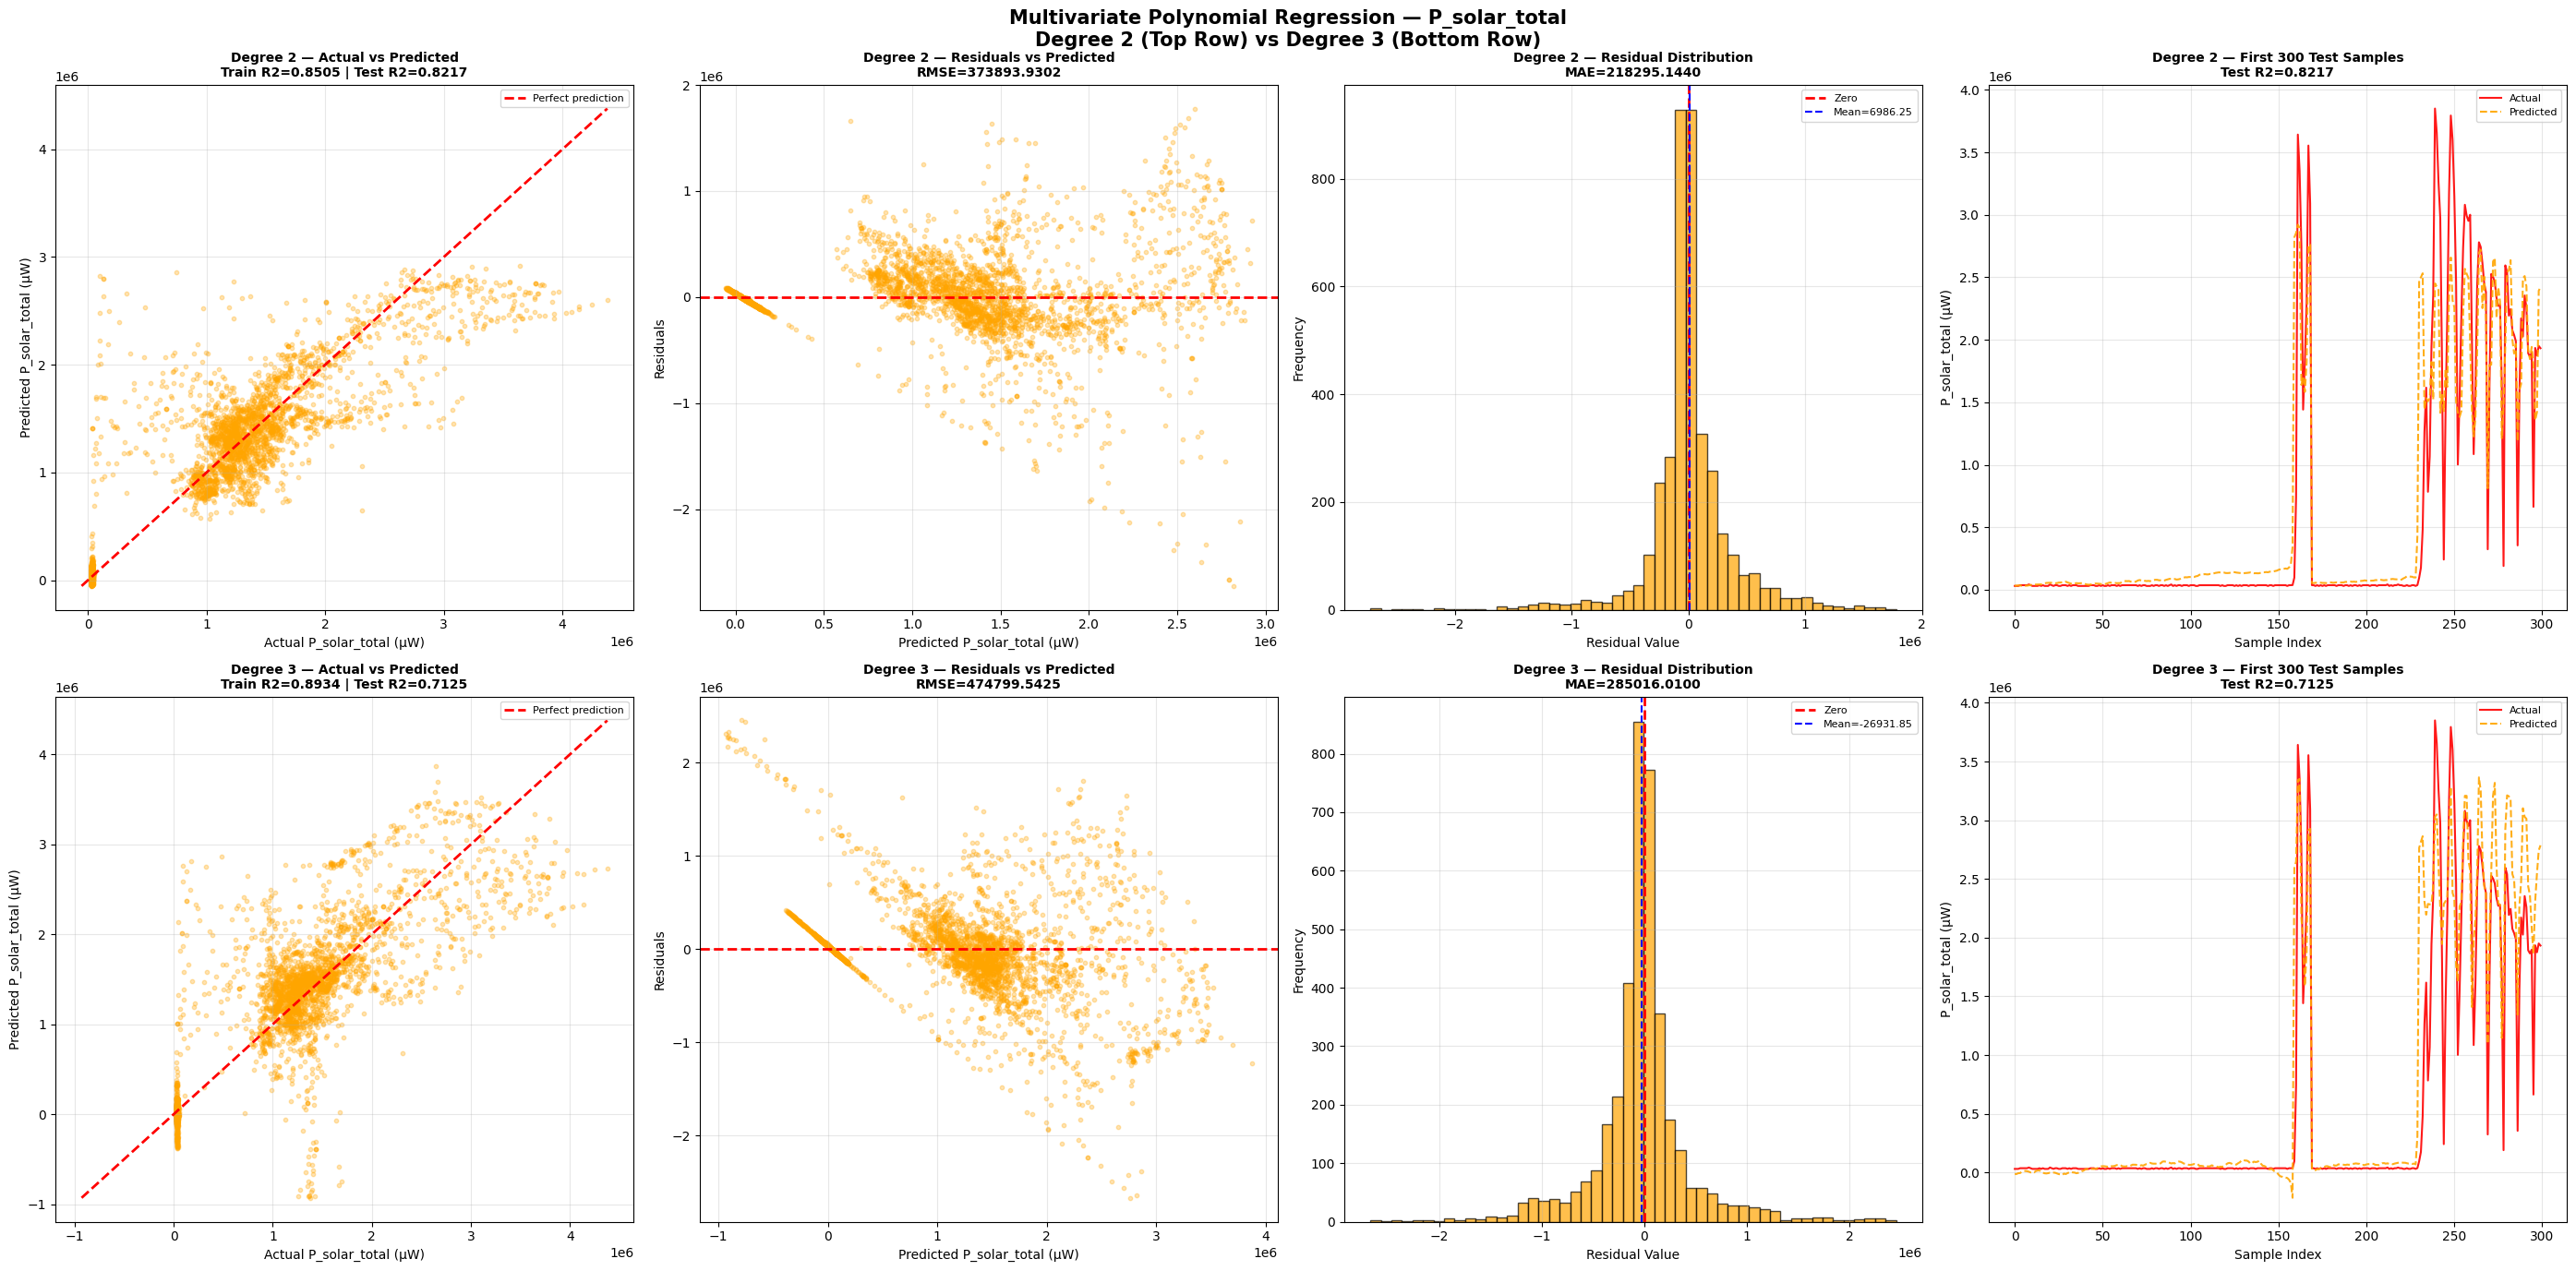

Detailed plots saved for P_solar_total


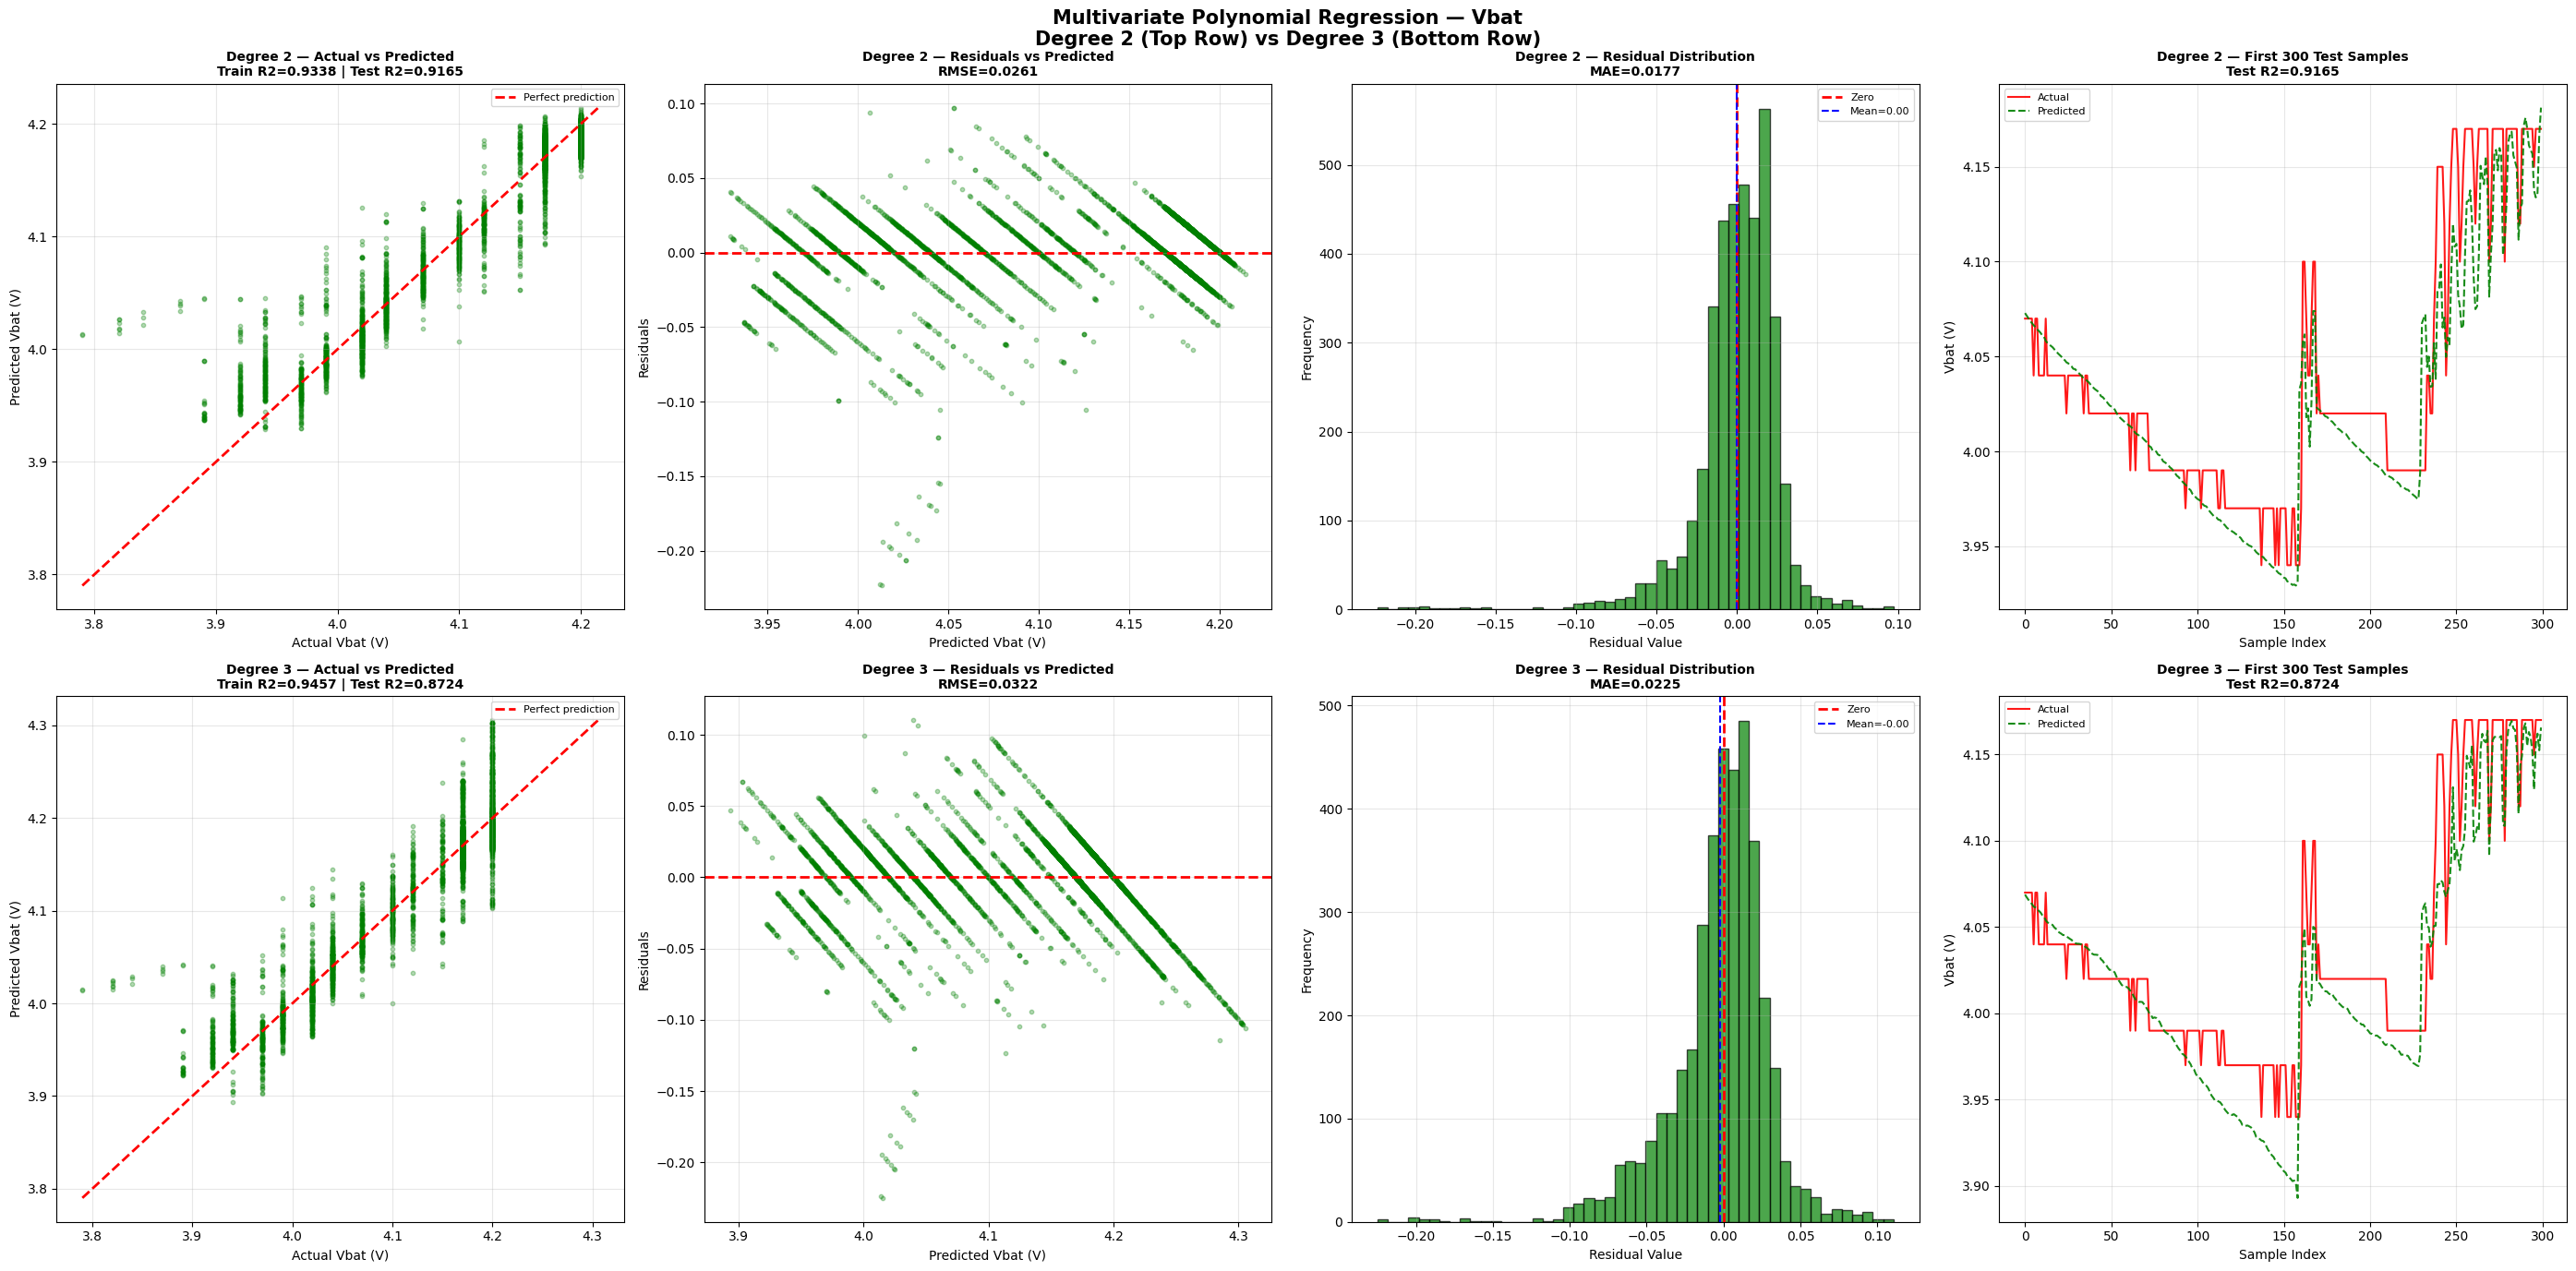

Detailed plots saved for Vbat


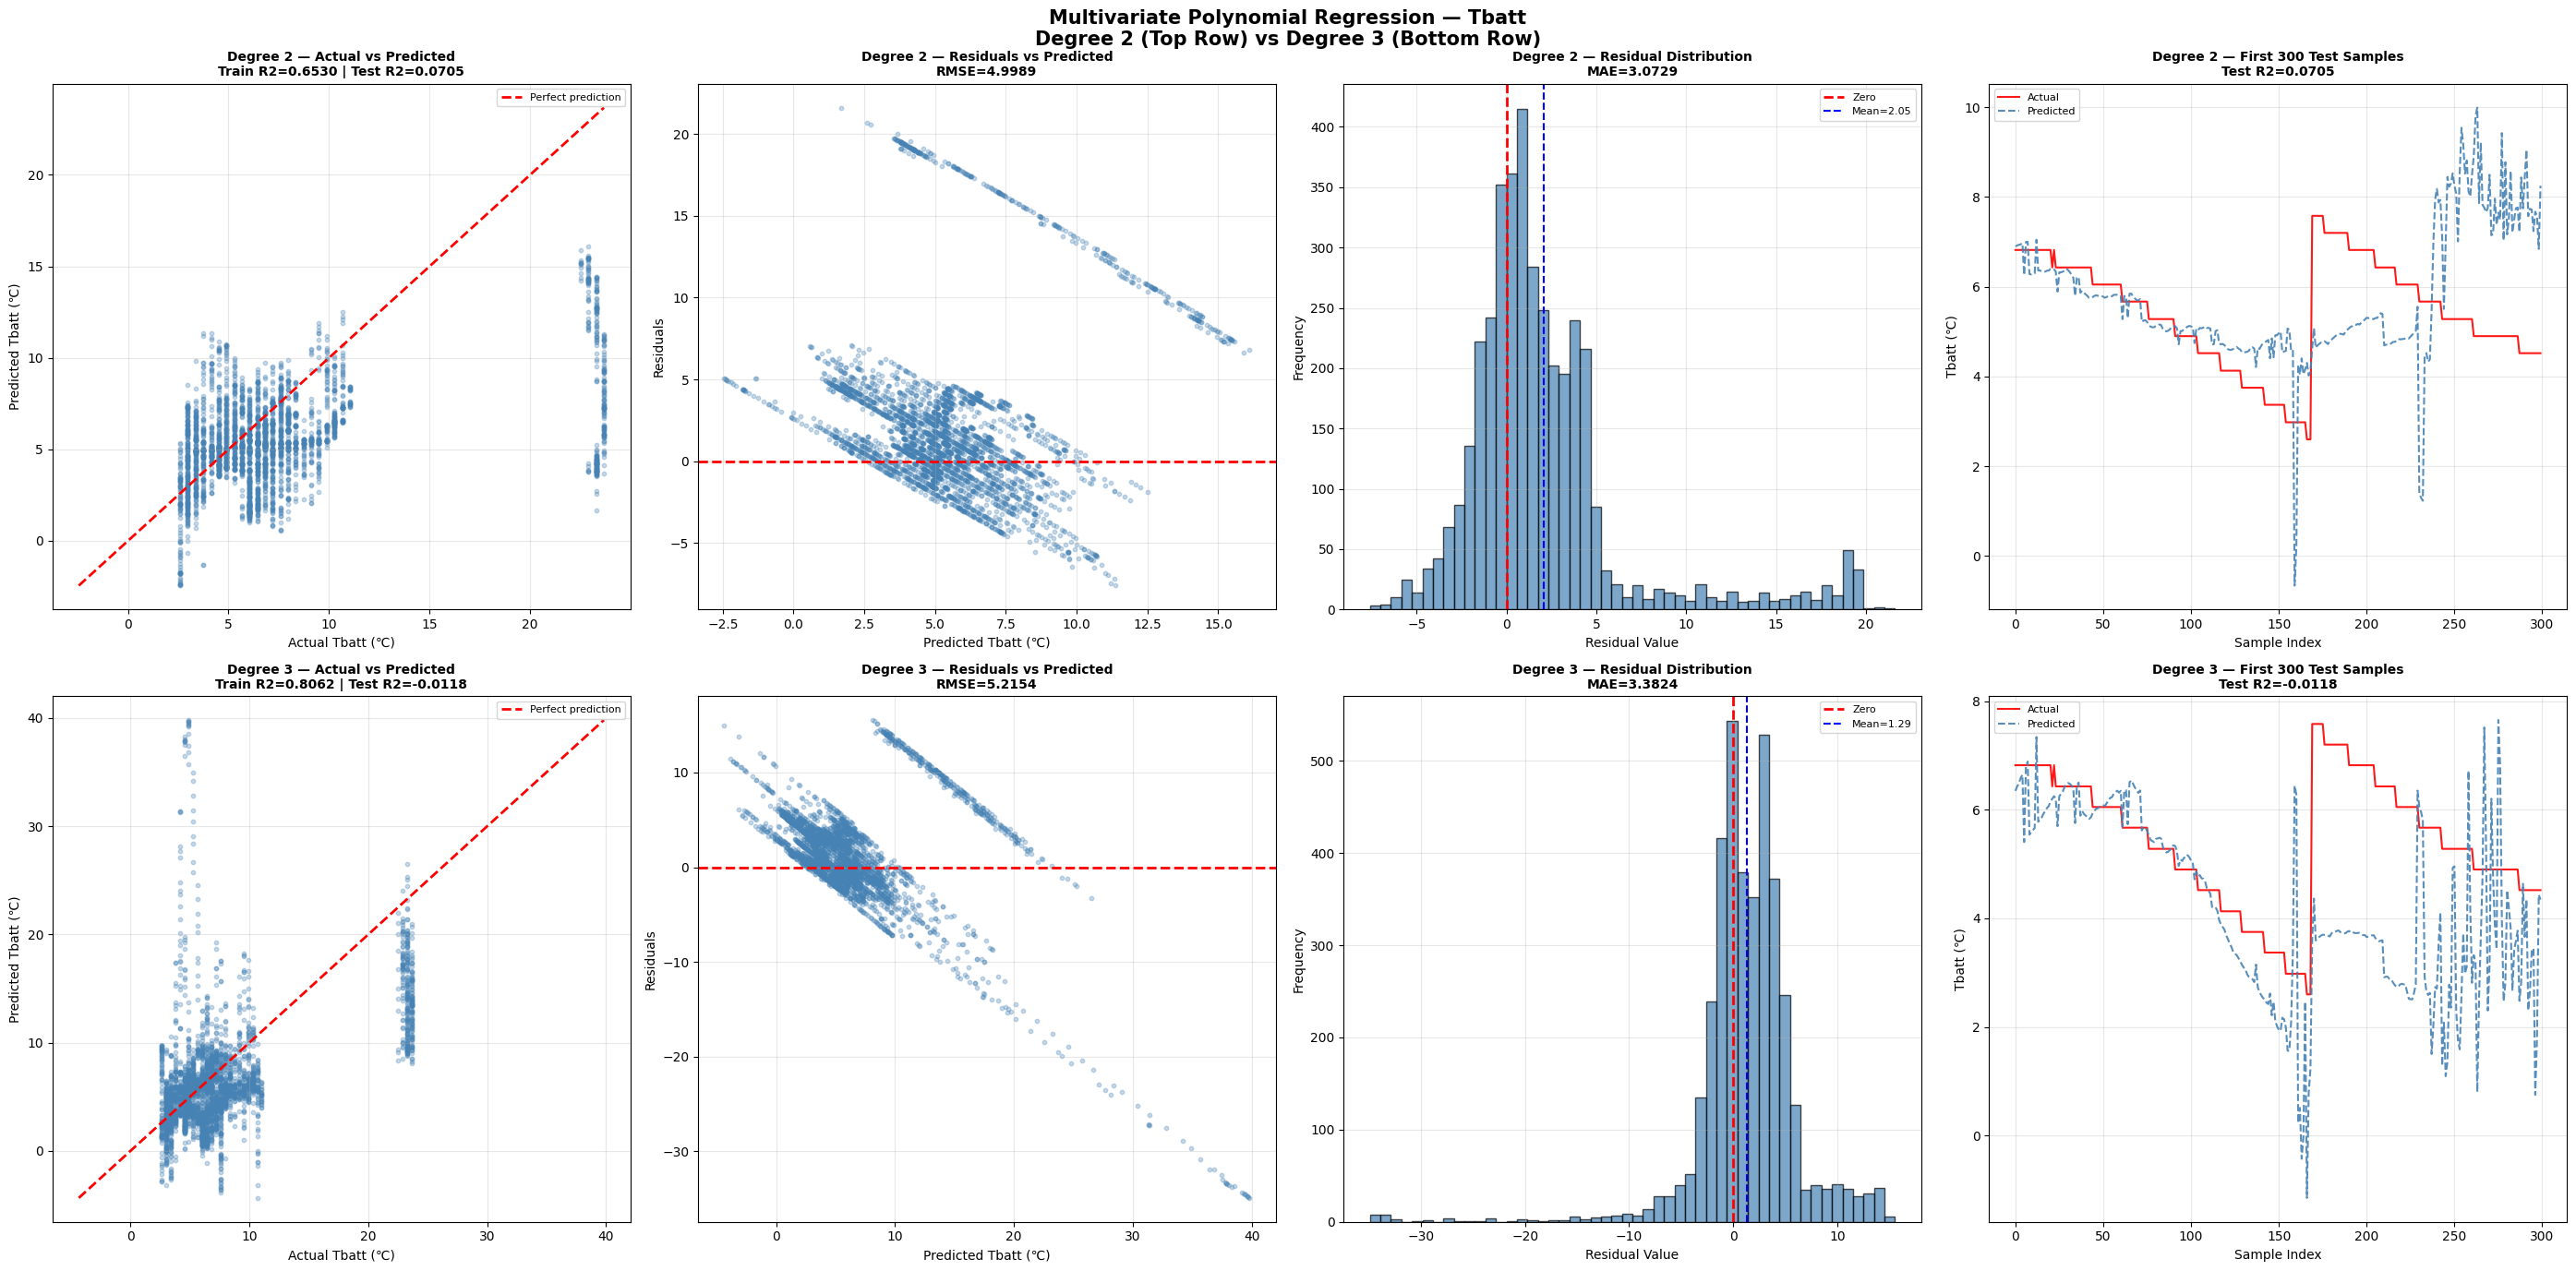

Detailed plots saved for Tbatt


In [27]:
# ============================================================
# MULTIVARIATE — INDIVIDUAL PLOTS PER TARGET PER DEGREE
# ============================================================

target_list  = ['P_solar_total', 'Vbat', 'Tbatt']
y_targets    = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]
colors       = ['orange', 'green', 'steelblue']

for name, ytarget, clr in zip(target_list, y_targets, colors):

    fig, axes = plt.subplots(2, 4, figsize=(28, 14))
    fig.suptitle(f'Multivariate Polynomial Regression — {name}\n'
                 f'Degree 2 (Top Row) vs Degree 3 (Bottom Row)',
                 fontsize=15, fontweight='bold')

    for row_idx, deg in enumerate([2, 3]):
        result   = multi_results_fixed[f'{name}_deg{deg}']
        y_pred   = result['y_pred']
        y_test   = result['y_test']
        train_r2 = result['train_r2']
        test_r2  = result['test_r2']
        rmse     = result['RMSE']
        mae      = result['MAE']
        residuals = y_test.values - y_pred

        # Plot 1: Actual vs Predicted scatter
        ax = axes[row_idx, 0]
        ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val],
                color='red', linewidth=2, linestyle='--',
                label='Perfect prediction')
        ax.set_title(f'Degree {deg} — Actual vs Predicted\n'
                     f'Train R2={train_r2:.4f} | Test R2={test_r2:.4f}',
                     fontweight='bold', fontsize=10)
        ax.set_xlabel(f'Actual {ytarget}')
        ax.set_ylabel(f'Predicted {ytarget}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        # Plot 2: Residuals vs Predicted
        ax2 = axes[row_idx, 1]
        ax2.scatter(y_pred, residuals, color=clr, alpha=0.3, s=10)
        ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
        ax2.set_title(f'Degree {deg} — Residuals vs Predicted\n'
                      f'RMSE={rmse:.4f}',
                      fontweight='bold', fontsize=10)
        ax2.set_xlabel(f'Predicted {ytarget}')
        ax2.set_ylabel('Residuals')
        ax2.grid(True, alpha=0.3)

        # Plot 3: Residual Distribution
        ax3 = axes[row_idx, 2]
        ax3.hist(residuals, bins=50, color=clr,
                 edgecolor='black', alpha=0.7)
        ax3.axvline(x=0, color='red', linestyle='--',
                    linewidth=2, label='Zero')
        ax3.axvline(x=residuals.mean(), color='blue',
                    linestyle='--', linewidth=1.5,
                    label=f'Mean={residuals.mean():.2f}')
        ax3.set_title(f'Degree {deg} — Residual Distribution\n'
                      f'MAE={mae:.4f}',
                      fontweight='bold', fontsize=10)
        ax3.set_xlabel('Residual Value')
        ax3.set_ylabel('Frequency')
        ax3.legend(fontsize=8)
        ax3.grid(True, alpha=0.3)

        # Plot 4: First 300 test samples overlay
        ax4 = axes[row_idx, 3]
        ax4.plot(range(300), y_test.values[:300],
                 color='red', linewidth=1.5,
                 label='Actual', alpha=0.9)
        ax4.plot(range(300), y_pred[:300],
                 color=clr, linewidth=1.5,
                 linestyle='--', label='Predicted', alpha=0.9)
        ax4.set_title(f'Degree {deg} — First 300 Test Samples\n'
                      f'Test R2={test_r2:.4f}',
                      fontweight='bold', fontsize=10)
        ax4.set_xlabel('Sample Index')
        ax4.set_ylabel(ytarget)
        ax4.legend(fontsize=8)
        ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'05_multivariate_{name}_detailed.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Detailed plots saved for {name}")

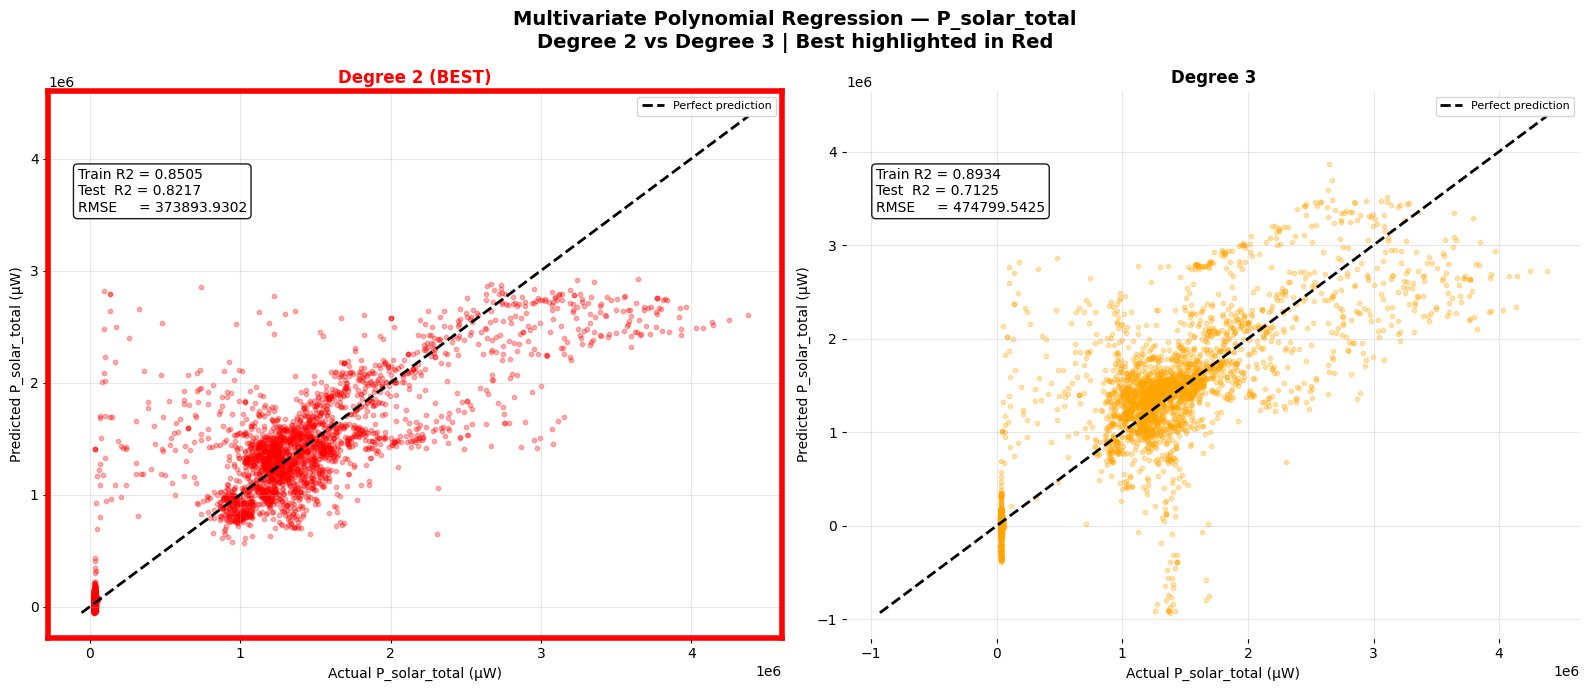

Saved: 05_multivariate_degrees_P_solar_total.png


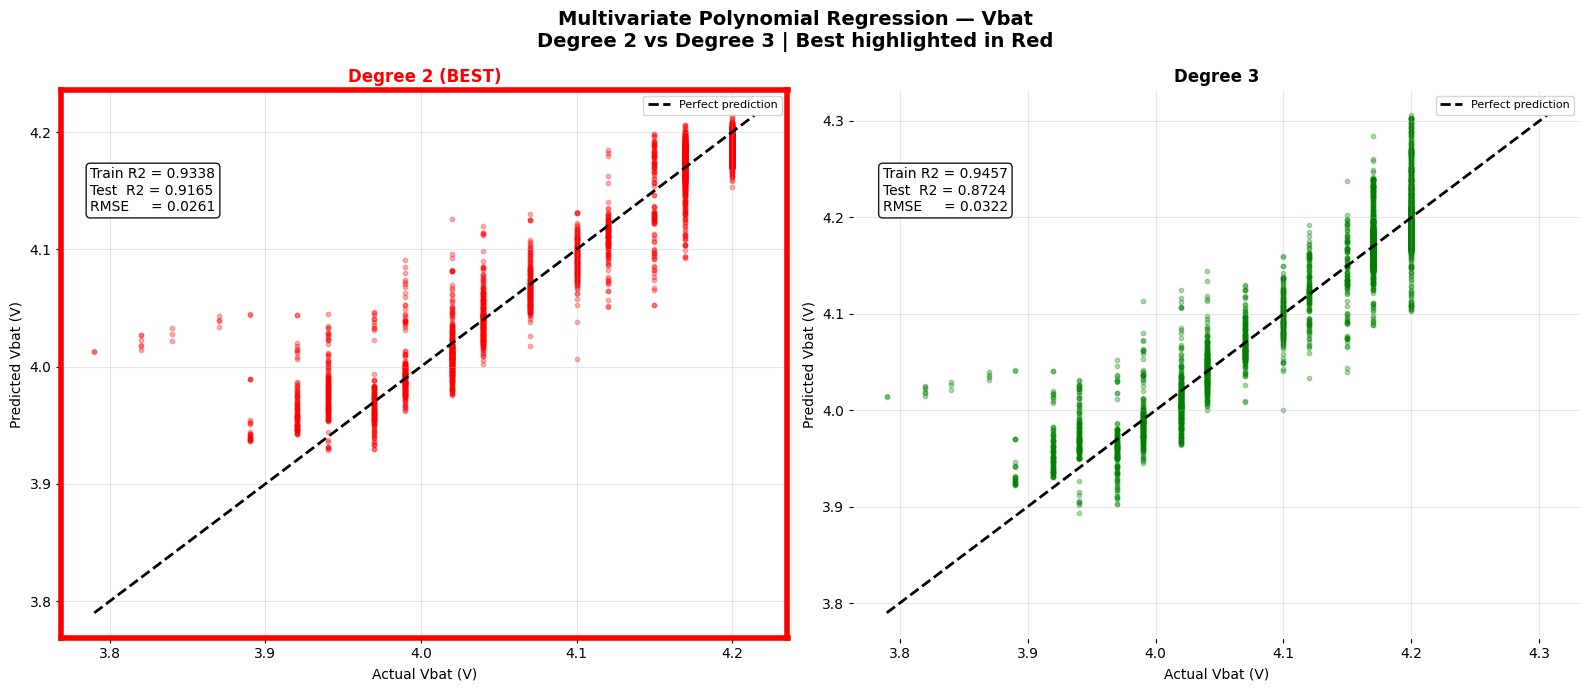

Saved: 05_multivariate_degrees_Vbat.png


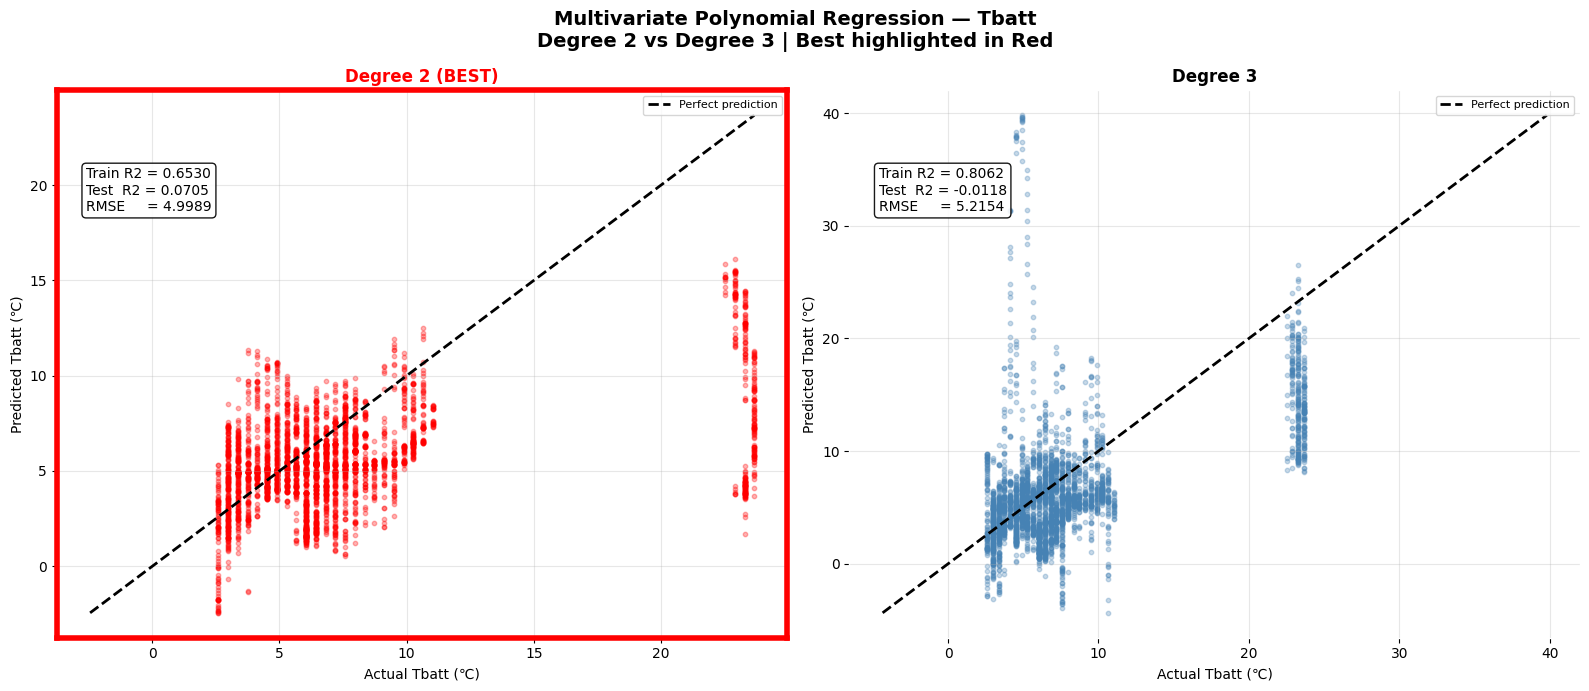

Saved: 05_multivariate_degrees_Tbatt.png


In [28]:
# ============================================================
# MULTIVARIATE
# ============================================================

target_list  = ['P_solar_total', 'Vbat', 'Tbatt']
y_targets    = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]
colors       = ['orange', 'green', 'steelblue']
best_degrees_multi = {
    'P_solar_total': 2,  # degree 2 had better test R2
    'Vbat'         : 2,
    'Tbatt'        : 2
}

for name, ytarget, clr in zip(target_list, y_targets, colors):

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Multivariate Polynomial Regression — {name}\n'
                 f'Degree 2 vs Degree 3 | Best highlighted in Red',
                 fontsize=14, fontweight='bold')

    best_deg = best_degrees_multi[name]

    for col_idx, deg in enumerate([2, 3]):
        result   = multi_results_fixed[f'{name}_deg{deg}']
        y_pred   = result['y_pred']
        y_test   = result['y_test']
        train_r2 = result['train_r2']
        test_r2  = result['test_r2']
        rmse     = result['RMSE']

        ax = axes[col_idx]

        # Highlight best degree with red border
        is_best = (deg == best_deg)
        border_color = 'red' if is_best else 'white'
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(4 if is_best else 1)

        # Actual vs Predicted scatter
        dot_color = 'red' if is_best else clr
        ax.scatter(y_test, y_pred,
                   color=dot_color, alpha=0.3, s=10)

        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val],
                color='black', linewidth=2,
                linestyle='--', label='Perfect prediction')

        title = f'Degree {deg}'
        if is_best:
            title += ' (BEST)'
        ax.set_title(title,
                     fontweight='bold',
                     fontsize=12,
                     color='red' if is_best else 'black')

        ax.set_xlabel(f'Actual {ytarget}')
        ax.set_ylabel(f'Predicted {ytarget}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax.annotate(f'Train R2 = {train_r2:.4f}\n'
                    f'Test  R2 = {test_r2:.4f}\n'
                    f'RMSE     = {rmse:.4f}',
                    xy=(0.04, 0.78),
                    xycoords='axes fraction',
                    fontsize=10,
                    bbox=dict(boxstyle='round',
                              facecolor='white', alpha=0.9))

    plt.tight_layout()
    fname = f'05_multivariate_degrees_{name}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

## Multivariate Polynomial Visualization

In single feature polynomial regression, the polynomial curve
can be plotted directly (X = feature, Y = target, curve = fit).

In multivariate polynomial regression with 12-13 input features,
the polynomial exists in high-dimensional space and cannot be
visualized as a curve. The correct diagnostic plot is:
  - Actual vs Predicted scatter → points close to diagonal = good fit
  - Residual distribution → centered at zero = unbiased predictions

This is why the multivariate plots show scatter plots instead of
curves, unlike the single feature degree plots shown earlier.

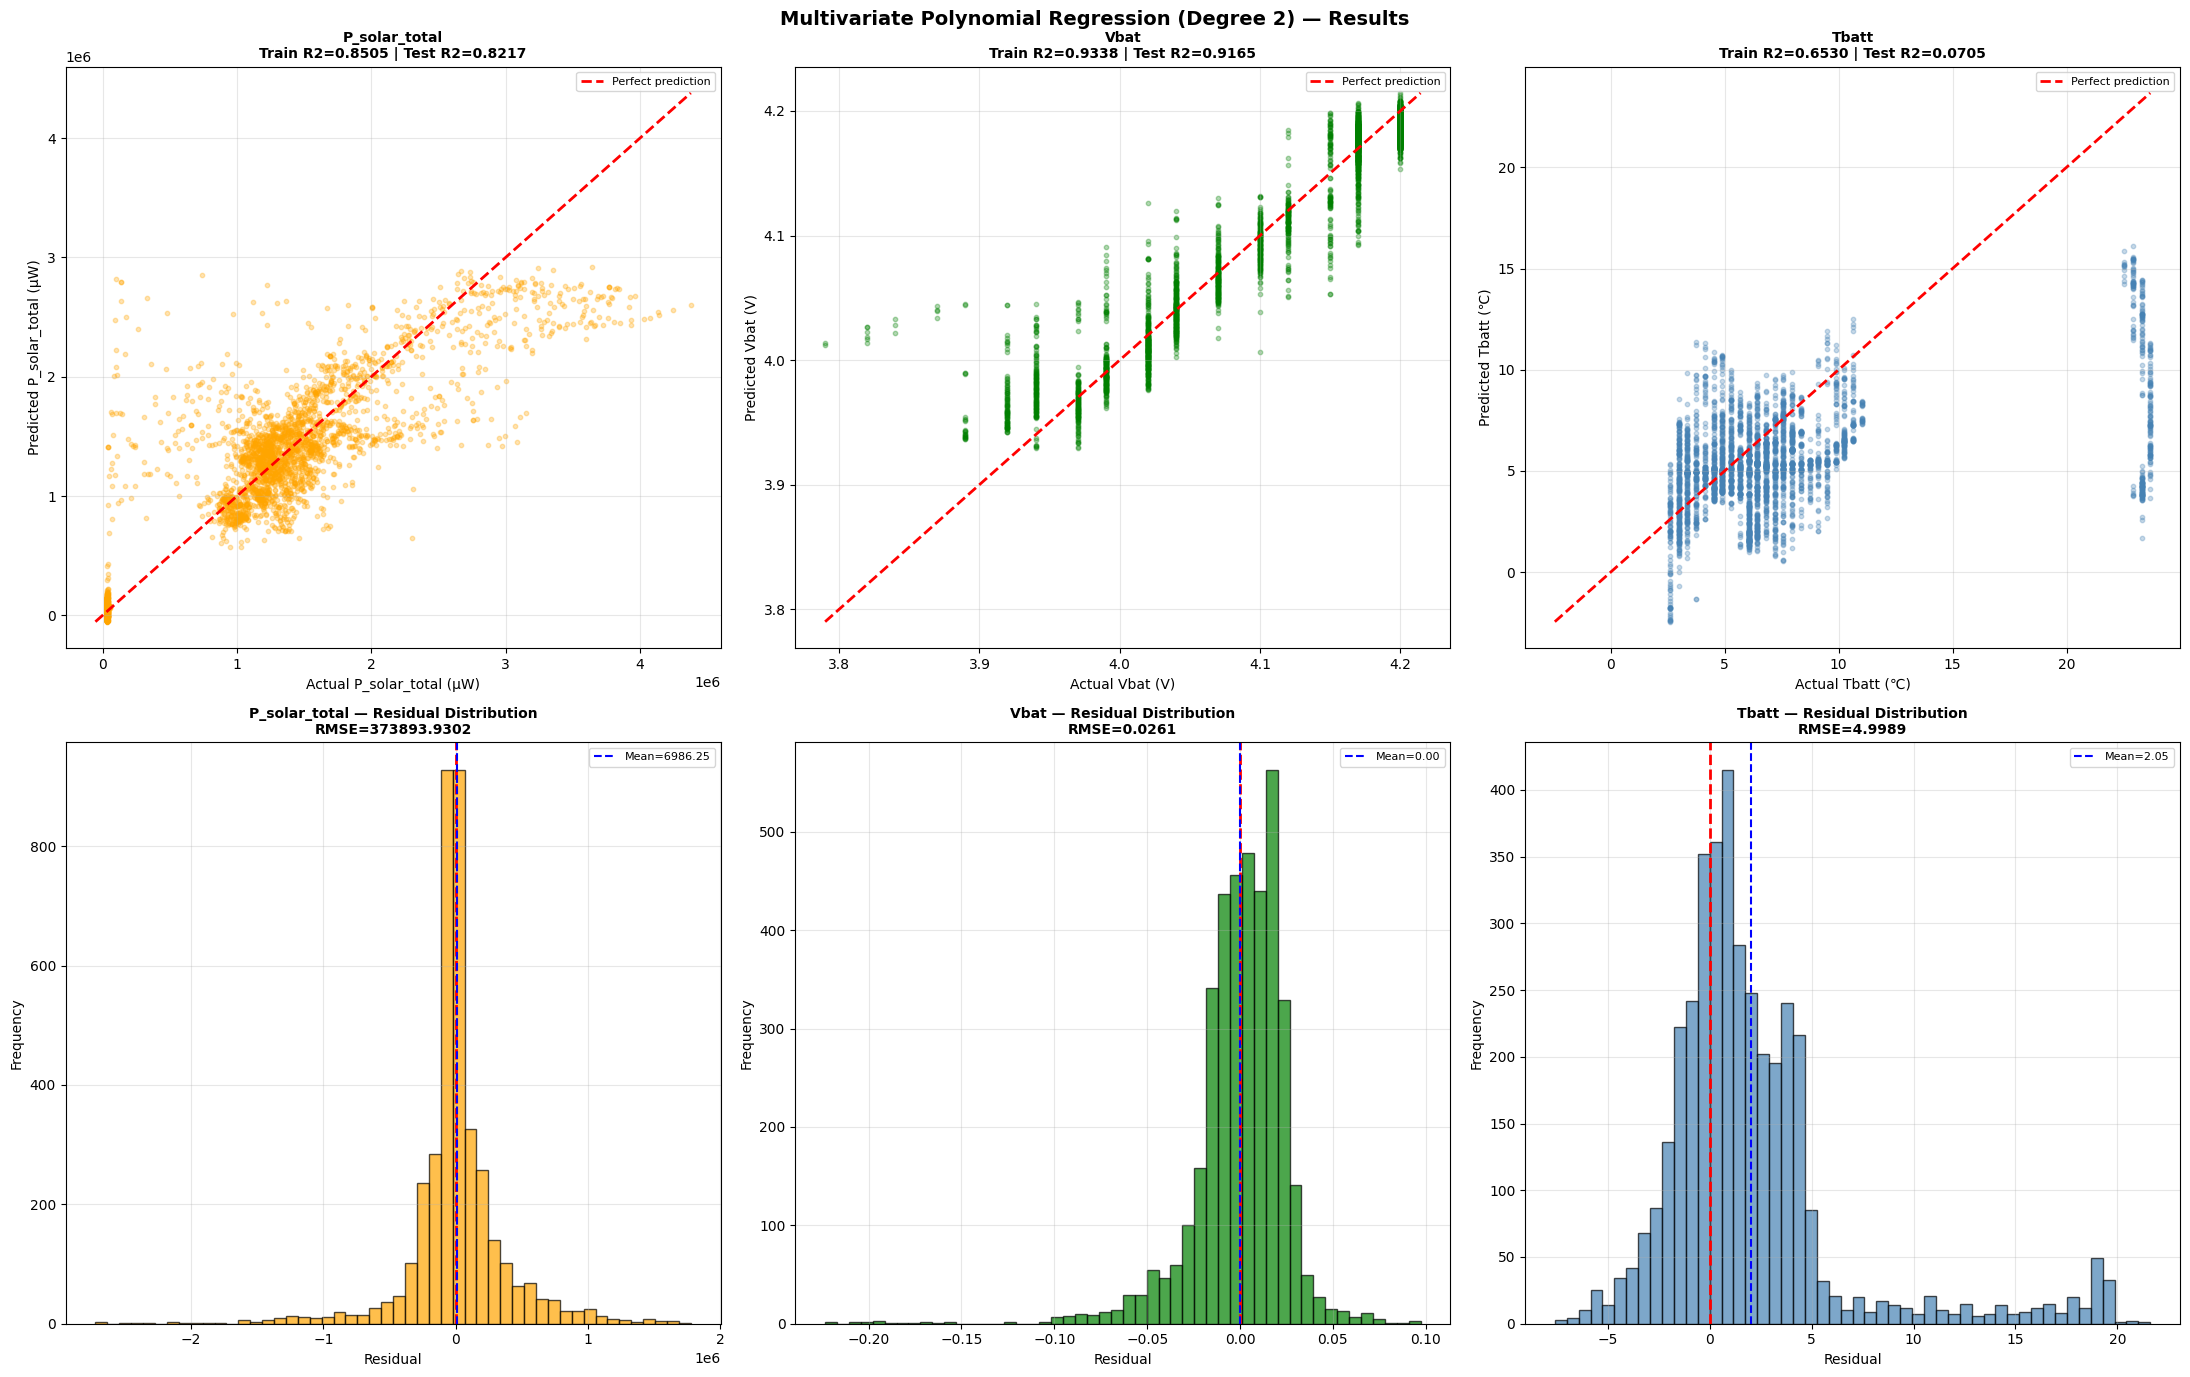

Multivariate results plot saved.

FINAL COMPARISON — SINGLE FEATURE vs MULTIVARIATE POLYNOMIAL

Target                   Single Feature   Multi Deg2   Multi Deg3            Best
--------------------------------------------------------------------------------
P_solar_total                    0.6635       0.8217       0.7125      Multi Deg2 (0.8217)
Vbat                             0.7820       0.9165       0.8724      Multi Deg2 (0.9165)
Tbatt                            0.0279       0.0705      -0.0118      Multi Deg2 (0.0705)


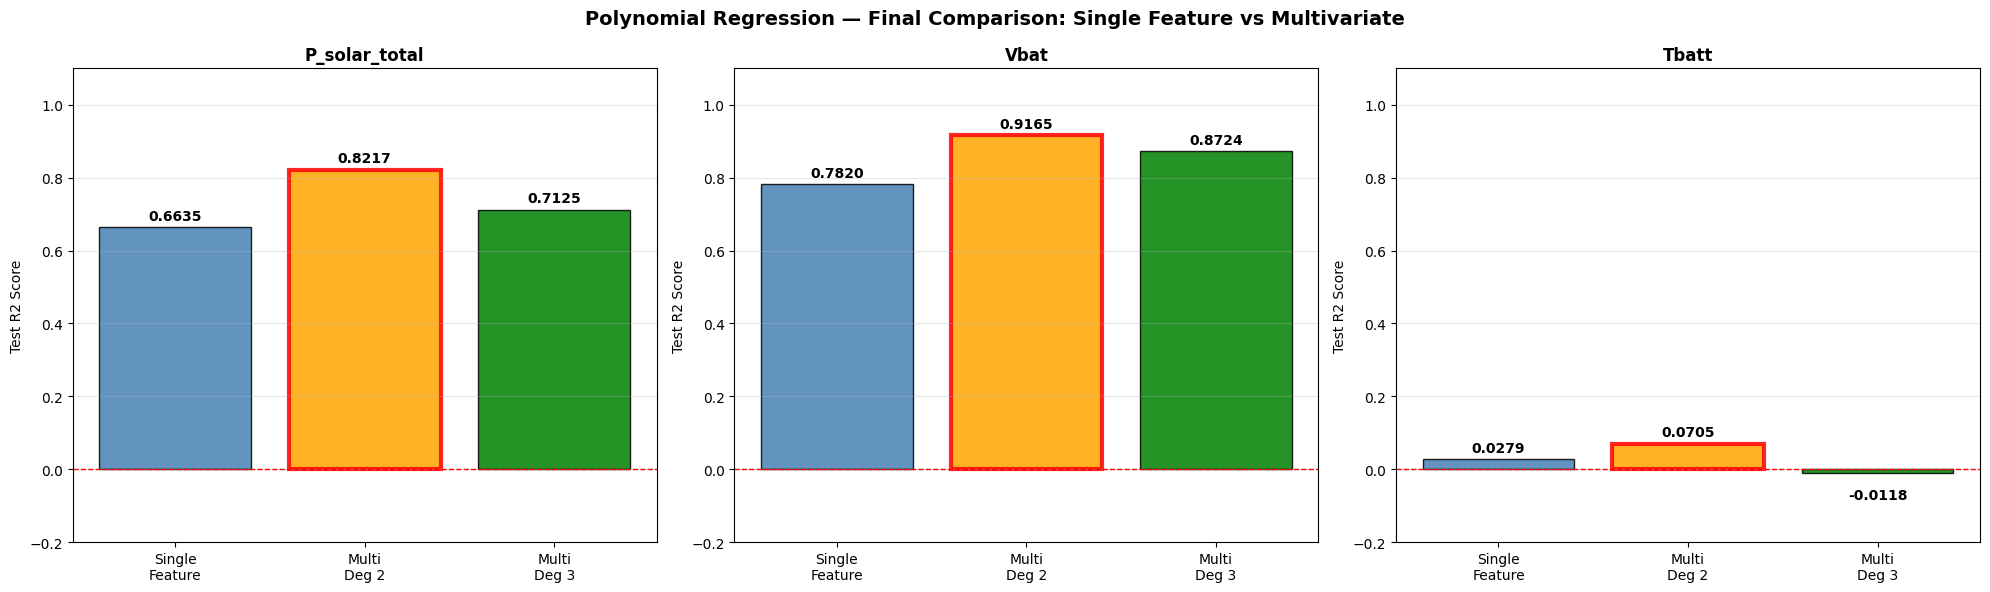

Final comparison plot saved.


In [29]:
# ============================================================
# PART 2: MULTIVARIATE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Multivariate Polynomial Regression (Degree 2) — Results',
             fontsize=14, fontweight='bold')

target_list  = ['P_solar_total', 'Vbat', 'Tbatt']
y_targets    = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]
colors       = ['orange', 'green', 'steelblue']

for idx, (name, ytarget, clr) in enumerate(zip(target_list, y_targets, colors)):
    result  = multi_results_fixed[f'{name}_deg2']
    y_pred  = result['y_pred']
    y_test  = result['y_test']
    train_r2= result['train_r2']
    test_r2 = result['test_r2']
    rmse    = result['RMSE']
    residuals = y_test.values - y_pred

    # Row 1: Actual vs Predicted
    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{name}\nTrain R2={train_r2:.4f} | Test R2={test_r2:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Row 2: Residual distribution
    ax2 = axes[1, idx]
    ax2.hist(residuals, bins=50, color=clr,
             edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax2.axvline(x=residuals.mean(), color='blue', linestyle='--',
                linewidth=1.5, label=f'Mean={residuals.mean():.2f}')
    ax2.set_title(f'{name} — Residual Distribution\nRMSE={rmse:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_multivariate_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Multivariate results plot saved.")

# ============================================================
# FINAL COMPARISON — PART 1 vs PART 2
# ============================================================

print("\n" + "=" * 75)
print("FINAL COMPARISON — SINGLE FEATURE vs MULTIVARIATE POLYNOMIAL")
print("=" * 75)

comparison = {
    'P_solar_total': {
        'Single Feature (Best Deg)' : best_metrics['P_solar_total']['R2'],
        'Multivariate Deg 2'        : multi_results_fixed['P_solar_total_deg2']['test_r2'],
        'Multivariate Deg 3'        : multi_results_fixed['P_solar_total_deg3']['test_r2'],
    },
    'Vbat': {
        'Single Feature (Best Deg)' : best_metrics['Vbat']['R2'],
        'Multivariate Deg 2'        : multi_results_fixed['Vbat_deg2']['test_r2'],
        'Multivariate Deg 3'        : multi_results_fixed['Vbat_deg3']['test_r2'],
    },
    'Tbatt': {
        'Single Feature (Best Deg)' : best_metrics['Tbatt']['R2'],
        'Multivariate Deg 2'        : multi_results_fixed['Tbatt_deg2']['test_r2'],
        'Multivariate Deg 3'        : multi_results_fixed['Tbatt_deg3']['test_r2'],
    }
}

print(f"\n{'Target':<20} {'Single Feature':>18} {'Multi Deg2':>12} "
      f"{'Multi Deg3':>12} {'Best':>15}")
print("-" * 80)

for name, vals in comparison.items():
    sf  = vals['Single Feature (Best Deg)']
    d2  = vals['Multivariate Deg 2']
    d3  = vals['Multivariate Deg 3']
    best_val  = max(sf, d2, d3)
    best_name = ['Single Feature', 'Multi Deg2', 'Multi Deg3'][[sf,d2,d3].index(best_val)]
    print(f"{name:<20} {sf:>18.4f} {d2:>12.4f} {d3:>12.4f} "
          f"{best_name:>15} ({best_val:.4f})")

# Visualization of comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Polynomial Regression — Final Comparison: Single Feature vs Multivariate',
             fontsize=14, fontweight='bold')

methods = ['Single\nFeature', 'Multi\nDeg 2', 'Multi\nDeg 3']
bar_colors = ['steelblue', 'orange', 'green']

for idx, (name, vals) in enumerate(comparison.items()):
    ax = axes[idx]
    r2_vals = list(vals.values())
    bars = ax.bar(methods, r2_vals,
                  color=bar_colors, edgecolor='black', alpha=0.85)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Test R2 Score')
    ax.set_ylim([-0.2, 1.1])
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, r2_vals):
        ypos = bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.07
        ax.text(bar.get_x() + bar.get_width()/2,
                ypos, f'{val:.4f}',
                ha='center', fontsize=10, fontweight='bold')
    best_idx = r2_vals.index(max(r2_vals))
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('04_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final comparison plot saved.")

# POLYNOMIAL REGRESSION —  CONCLUSION  
### Dataset: TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)

---

## ALGORITHM SUMMARY

Polynomial Regression extends Linear Regression by creating higher degree terms (x², x³, ..., xⁿ) and interaction terms between features. It captures non-linear relationships while still using the OLS minimization framework of Linear Regression internally.

---

# PART 1 — SINGLE FEATURE POLYNOMIAL (V_panel_avg, Degrees 1–16)

| Target         | Best Degree | Test R² | vs Linear R² | Improvement |
|---------------|------------|---------|--------------|-------------|
| P_solar_total | 12         | 0.6635  | 0.5723       | +15.9%      |
| Vbat          | 14         | 0.7820  | 0.6701       | +16.7%      |
| Tbatt         | 14         | 0.0279  | -0.1791      | rescued     |

**Key Finding:** R² improvements plateau after degree 4 for P_solar_total. Degrees beyond 4 add minimal value while increasing overfitting risk. Tbatt improved from negative R² to near-zero — still fundamentally unpredictable from a single voltage feature.

---

# PART 2 — MULTIVARIATE POLYNOMIAL (Degrees 2 and 3)

| Target         | Degree 2 R² | Degree 3 R² | Winner   |
|---------------|------------|------------|----------|
| P_solar_total | 0.8217     | 0.7125     | Degree 2 |
| Vbat          | 0.9165     | 0.8724     | Degree 2 |
| Tbatt         | 0.0705     | -0.0118    | Degree 2 |

**Key Finding:** Degree 2 consistently outperforms Degree 3 across all targets. Degree 3 overfits — train R² increases but test R² drops, confirming the bias–variance tradeoff in action.

---

# DATA LEAKAGE ANALYSIS (Critical Finding)

Three separate leakage sources were identified and corrected:

1. **P_solar_total:** V×I cross terms reconstructed P = V×I formula  
2. **Vbat:** Vbat as both input and target (self-prediction)  
3. **Tbatt:** DeltaT = Tbatt - T_panel_avg (arithmetic leak)  

This demonstrates the importance of feature auditing before applying polynomial expansion in satellite EPS datasets.

---

# OVERALL BEST — MULTIVARIATE DEGREE 2

- **P_solar_total:** R² = 0.8217 (best so far across all notebooks)  
- **Vbat:** R² = 0.9165 (excellent performance)  
- **Tbatt:** R² = 0.0705 (weak — thermal dynamics too complex)  

---

# COMPARISON WITH SIMPLE LINEAR REGRESSION

- Simple Linear (single feature): P_solar_total R² = 0.5723  
- Polynomial Multivariate Degree 2: P_solar_total R² = 0.8217  
- Improvement: +43.6% relative improvement  

This confirms that the relationship between panel voltages/temperatures and solar power generation is non-linear — consistent with the physics of photovoltaic cells whose output depends non-linearly on irradiance and temperature.

---

### Reference  
Jara et al. (2022), *Data in Brief*  
DOI: 10.1016/j.dib.2022.108697